# Seller Churn Prediction in Brazilian E-Commerce Using Machine Learning

**Author:** Jefferson, Alicia, Azhar
**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Period:** 2016–2018

In [3]:
# ============================================================
# Library Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import files

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_score,
                                     learning_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, make_scorer, fbeta_score)
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries imported successfully.')

Libraries imported successfully.


In [4]:

# ============================================================
# Load All Datasets
# ============================================================

from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/OlistData/'

customers   = pd.read_csv(f'{DATA_PATH}olist_customers_dataset.csv')
orders      = pd.read_csv(f'{DATA_PATH}olist_orders_dataset.csv')
order_items = pd.read_csv(f'{DATA_PATH}olist_order_items_dataset.csv')
payments    = pd.read_csv(f'{DATA_PATH}olist_order_payments_dataset.csv')
reviews     = pd.read_csv(f'{DATA_PATH}olist_order_reviews_dataset.csv')
products    = pd.read_csv(f'{DATA_PATH}olist_products_dataset.csv')
sellers     = pd.read_csv(f'{DATA_PATH}olist_sellers_dataset.csv')
geolocation = pd.read_csv(f'{DATA_PATH}olist_geolocation_dataset.csv')
category_translation = pd.read_csv(f'{DATA_PATH}product_category_name_translation.csv')

print('All datasets loaded successfully.')

Mounted at /content/drive
All datasets loaded successfully.


---
## 1. Introduction

### 1.1 Background

The rapid growth of e-commerce has intensified competition among online marketplaces, making seller retention an increasingly important business priority. Unlike traditional retailers, marketplace platforms rely on third-party sellers to provide product variety, maintain inventory availability, and generate transaction revenue. Therefore, the sustainability of a marketplace depends not only on attracting customers but also on retaining active sellers.

Seller churn, defined as the discontinuation of selling activities on the platform, can negatively impact business performance by reducing transaction volume, limiting product assortment, and increasing the cost of acquiring new sellers. In the context of Brazilian e-commerce, where marketplace penetration is growing rapidly but seller onboarding costs remain significant, understanding what drives seller attrition is essential for supporting long-term marketplace growth.

This project uses the Olist Brazilian E-Commerce Public Dataset, which contains approximately 100,000 real transactions from 2016 to 2018 involving 3,095 registered sellers across 23 Brazilian states. The dataset provides a comprehensive view of seller activity, including transaction frequency, revenue, customer reviews, delivery performance, and product catalog diversity. All of which can serve as early indicators of churn risk.

### 1.2 Problem Statement

Seller churn can negatively affect marketplace performance by decreasing transaction revenue and reducing the availability and diversity of products offered to customers. Since sellers often become inactive without prior warning, e-commerce companies face challenges in implementing timely retention strategies.

From the dataset, preliminary analysis reveals that over 50% of sellers who were active before mid-2018 had no transactions in the following 90 days. Churned sellers averaged only 12.7 orders and R\$2,153 in total revenue, compared to active sellers who averaged 63.4 orders and R\$8,061 — indicating that lower engagement and revenue are strongly associated with attrition.

Therefore, there is a need for a predictive model that can identify sellers at risk of churn before they leave the platform, enabling proactive retention interventions rather than reactive measures after the seller has already gone inactive.

### 1.3 Goal

The objective of this project is to develop a machine learning model to predict seller churn using historical transaction data from the Olist Brazilian E-Commerce Public Dataset. By identifying sellers with a high risk of churn, the model can support e-commerce companies in implementing proactive retention strategies, reducing potential revenue loss, and improving the sustainability of the seller ecosystem.

### 1.4 Analytical Approach

This project frames seller churn prediction as a supervised binary classification problem, where the objective is to predict whether a seller will churn (1) or remain active (0) within a 90-day horizon based on historical behavioral data.

---

#### Business Context

The problem is driven by asymmetric misclassification costs:

- Missing a churner (False Negative) leads to significant revenue loss and acquisition cost.
- A false alarm (False Positive) incurs only a relatively small intervention cost.

Because False Negatives are substantially more costly than False Positives, the modeling objective prioritizes recall.

---

#### Evaluation Metrics

The primary evaluation metric is **F2-Score**, which places higher weight on Recall (β = 2):

$$
F_\beta = (1 + \beta^2)\frac{Precision \cdot Recall}{(\beta^2 \cdot Precision) + Recall}
$$

F2 is chosen because it better reflects the business requirement of minimizing missed churners.

- **Recall**: ability to capture actual churners  
- **Precision**: correctness of churn predictions  
- **ROC-AUC / PR-AUC**: overall ranking and discrimination quality  
- **Accuracy**: not suitable due to class imbalance and cost asymmetry  

---

#### Modeling Pipeline

1. Feature engineering from seller-level behavioral data  
2. Training multiple baseline models (logistic regression, tree-based models, boosting models)  
3. Hyperparameter tuning using cross-validation optimized for F2-score  
4. Threshold optimization based on validation performance  
5. Final model evaluation using optimized thresholds  
6. SHAP-based interpretability to identify key churn drivers  
7. Business evaluation using cost-benefit analysis and ROI estimation  

---

#### Threshold Optimization Strategy

Default probability threshold (0.50) is not used. Instead, an optimal cutoff is selected by sweeping predicted probabilities on the validation set and choosing the threshold that maximizes the F2-score. This ensures alignment between model decisions and the asymmetric business cost structure.

---
## 2. Data Understanding

### 2.1 Dataset Overview

This project utilizes the Brazilian E-Commerce Public Dataset by Olist, a publicly available collection of real transactional records from Brazilian online marketplaces.

For a **seller churn** use case, the focus shifts from the customer journey to **seller-side transactional behavior over time** — i.e. how consistently a seller receives orders, how well they perform operationally, and whether that activity eventually stops. Of the 9 available tables, **7 are relevant** and used in this analysis; 2 are excluded as they describe the buyer side rather than the seller side.

| Table | Records | Used? | Relevance to Seller Churn |
|-------|--------:|:---:|-------------|
| `olist_order_items_dataset` | 112,650 | ✅ | **Core table** — links every transaction to a `seller_id`; the backbone for measuring seller activity, frequency, and recency |
| `olist_orders_dataset` | 99,441 | ✅ | Provides order status & timestamps — needed to determine *when* a seller's last transaction occurred and whether orders were fulfilled or canceled |
| `olist_sellers_dataset` | 3,095 | ✅ | Seller attributes (location) — candidate features and the entity-level table the churn label is built around |
| `olist_products_dataset` | 32,951 | ✅ | Product attributes sold by each seller — used to derive catalog diversity features (e.g. number of distinct categories) |
| `product_category_name_translation` | 71 | ✅ | Translates product categories (PT → EN) for readability |
| `olist_order_payments_dataset` | 103,886 | ✅ | Payment values — basis for *monetary* (revenue) features per seller |
| `olist_order_reviews_dataset` | 104,719 | ✅ | Review scores — proxy for seller service quality, a potential churn driver |
| `olist_customers_dataset` | 99,441 | ❌ | Describes buyer identity/location only — not informative about seller behavior |
| `olist_geolocation_dataset` | 1,000,163 | ❌ | Extremely granular zip-code coordinates; seller location is already sufficiently captured in `olist_sellers_dataset` |

These 7 tables are linked through `order_id`, `product_id`, and most importantly **`seller_id`** — the key around which all transactional history is aggregated to build seller-level recency, frequency, monetary (RFM), and service-quality features, and ultimately the churn label itself.

### 2.2 Dataset Structure

In [5]:
# ============================================================
# Dataset Summary Table
# ============================================================

datasets = {
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

summary = pd.DataFrame([
    {
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Missing Values': df.isnull().sum().sum(),
        'Missing (%)': round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
        'Duplicates': df.duplicated().sum()
    }
    for name, df in datasets.items()
])

print(f"Total tables: {len(datasets)}")
print(f"Total records across all tables: {summary['Rows'].sum():,}")
print()
summary

Total tables: 7
Total records across all tables: 451,318



,Dataset,Rows,Columns,Missing Values,Missing (%),Duplicates
0,orders,99441,8,4908,0.62,0
1,order_items,112650,7,0,0.00,0
2,payments,103886,5,0,0.00,0
3,reviews,99224,7,145903,21.01,0
4,products,32951,9,2448,0.83,0
5,sellers,3095,4,0,0.00,0
6,category_translation,71,2,0,0.00,0


In [6]:
for name, df in datasets.items():
    print(f'\n{"=" * 55}')
    print(f' {name.upper()} — {df.shape[0]:,} rows x {df.shape[1]} cols')
    print(f'{"=" * 55}')
    info_df = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notnull().sum(),
        'null': df.isnull().sum(),
        'unique': df.nunique()
    })
    print(info_df.to_string())
    print()


 ORDERS — 99,441 rows x 8 cols
                                dtype  non_null  null  unique
order_id                       object     99441     0   99441
customer_id                    object     99441     0   99441
order_status                   object     99441     0       8
order_purchase_timestamp       object     99441     0   98875
order_approved_at              object     99281   160   90733
order_delivered_carrier_date   object     97658  1783   81018
order_delivered_customer_date  object     96476  2965   95664
order_estimated_delivery_date  object     99441     0     459


 ORDER_ITEMS — 112,650 rows x 7 cols
                       dtype  non_null  null  unique
order_id              object    112650     0   98666
order_item_id          int64    112650     0      21
product_id            object    112650     0   32951
seller_id             object    112650     0    3095
shipping_limit_date   object    112650     0   93318
price                float64    112650     0    5968


**Dataset Insights:**

- Missing values in `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date` columns are expected for orders that were not completed or cancelled.

- `order_items` and `payments` have a one-to-many relationship with `orders`, requiring aggregation before analysis.

- `review_comment_title` and `review_comment_message` contain many missing values, but `review_score` is complete and usable.

- The `products` dataset has **610 missing product categories** and **2 missing dimension records**, requiring preprocessing.

- The `sellers` dataset is complete with no missing values.

- The category translation table has fewer entries than the product categories, so translation coverage should be verified after merging.

### 2.3 Data Preview

In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [10]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [11]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


In [12]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [13]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### 2.4 Data Dictionary

This documents every column of the **7 tables used** (`customers` and `geolocation` are excluded entirely — see Section 2.1). Columns not used are explicitly marked and removed during cleaning (Section 3).

---

#### Orders Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `order_id` | object | Unique order identifier | KEEP |
| `customer_id` | object | Foreign key to customers (not used) | DROP |
| `order_status` | object | Order status | KEEP |
| `order_purchase_timestamp` | object → datetime | Order creation timestamp | KEEP |
| `order_approved_at` | object → datetime | Payment approval timestamp | DROP |
| `order_delivered_carrier_date` | object → datetime | Carrier handover timestamp | DROP |
| `order_delivered_customer_date` | object → datetime | Actual delivery date | KEEP |
| `order_estimated_delivery_date` | object → datetime | Estimated delivery date | KEEP |

---

#### Order Items Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `order_id` | object | Foreign key to orders | KEEP |
| `order_item_id` | int | Item sequence within order | KEEP |
| `product_id` | object | Foreign key to products | KEEP |
| `seller_id` | object | Seller identifier | KEEP |
| `shipping_limit_date` | object | Shipping deadline | DROP |
| `price` | float | Item price | KEEP |
| `freight_value` | float | Shipping cost | KEEP |

---

#### Sellers Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `seller_id` | object | Unique seller identifier | KEEP |
| `seller_zip_code_prefix` | int | ZIP code prefix | DROP |
| `seller_city` | object | City | DROP |
| `seller_state` | object | State | KEEP |

---

#### Products Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `product_id` | object | Unique product identifier | KEEP |
| `product_category_name` | object | Product category name (Portuguese) — translated then dropped | DROP |
| `product_name_lenght` | float | Name length | DROP |
| `product_description_lenght` | float | Description length | DROP |
| `product_photos_qty` | float | Number of photos | DROP |
| `product_weight_g` | float | Weight | DROP |
| `product_length_cm` | float | Length | DROP |
| `product_height_cm` | float | Height | DROP |
| `product_width_cm` | float | Width | DROP |

---

#### Product Category Translation Dataset

| Feature | Type (raw) | Description |
|---------|-----------|-------------|
| `product_category_name` | object | Category name (join key) |
| `product_category_name_english` | object | English category name |

---

#### Payments Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `order_id` | object | Foreign key to orders | KEEP |
| `payment_sequential` | int | Payment sequence | DROP |
| `payment_type` | object | Payment method | DROP |
| `payment_installments` | int | Number of installments | DROP |
| `payment_value` | float | Payment amount | KEEP |

---

#### Reviews Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `review_id` | object | Unique review identifier | DROP |
| `order_id` | object | Foreign key to orders | KEEP |
| `review_score` | int | Customer rating (1–5) | KEEP |
| `review_comment_title` | object | Review title | DROP |
| `review_comment_message` | object | Review text | DROP |
| `review_creation_date` | object | Review date | DROP |
| `review_answer_timestamp` | object | Seller response timestamp | DROP |

---
## 3. Data Cleaning
Cleaning is performed **per dataset**, directly on the original variables loaded in Section 2. Each dataset follows a consistent 4-step process (steps are explicitly skipped when not applicable, with justification):

1. **Fix data types** — convert columns with incorrect data types (e.g., string dates → datetime)
2. **Check duplicates** — ensure no unexpected duplicate rows or keys exist
3. **Handle invalid data** — treat missing values and resolve values that are not logically valid
4. **Drop unused columns** — remove columns marked as unused in the Data Dictionary (Section 2.3) before merging

The final merge is performed only after all individual datasets are cleaned (Section 3.7).

### 3.1 Orders Dataset

**Step 1 — Fix data types:** the timestamp columns are currently stored as `object` (string) and need to be converted to `datetime` so they can be used to compute recency, tenure, and delivery lateness.

In [14]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

print(orders[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


**Step 2 — Check duplicates:** make sure no `order_id` appears more than once (ideally 1 row = 1 order).

In [15]:
print('Full duplicate rows :', orders.duplicated().sum())
print('Duplicate order_id  :', orders['order_id'].duplicated().sum())


Full duplicate rows : 0
Duplicate order_id  : 0


**Step 3 — Handle invalid data:** missing values in `approved_at`/`delivered_*` are **not removed**, since they reflect orders that were genuinely never completed (e.g. status `canceled`, `unavailable`, `processing`) — not a data error. Dropping them would discard valuable information about failed orders, which is relevant to a seller's activity history.

In [16]:
print('Missing values in date columns (kept on purpose, not an error):')
print(orders[date_cols].isna().sum())

Missing values in date columns (kept on purpose, not an error):
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


**Step 4 — Drop unused columns:** per the Data Dictionary, `customer_id` (the `customers` table is not used), `order_approved_at`, and `order_delivered_carrier_date` are dropped — they do not feed into any feature in Section 6.

In [17]:
orders = orders.drop(columns=['customer_id', 'order_approved_at', 'order_delivered_carrier_date'])

print('orders shape after cleaning:', orders.shape)
orders.head()

orders shape after cleaning: (99441, 5)


,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26


### 3.2 Order Items Dataset

**Step 1 — Fix data types:** `shipping_limit_date` is still `object`, but since it will dropped in Step 4 anyway, no conversion is needed here.

In [18]:
print(order_items.dtypes)

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


**Step 2 — Check duplicates:** check for full duplicate rows at the order-item level.

In [19]:
print('Full duplicate rows:', order_items.duplicated().sum())

Full duplicate rows: 0


**Step 3 — Handle invalid data:** `price` should always be positive (a real transaction). Rows with `price <= 0` are treated as invalid and dropped.

In [20]:
before = order_items.shape[0]
order_items = order_items[order_items['price'] > 0]
after = order_items.shape[0]

print(f'Rows before: {before} -> after: {after} (dropped: {before - after})')

Rows before: 112650 -> after: 112650 (dropped: 0)


**Step 4 — Drop unused columns:** `shipping_limit_date` is removed per the Data Dictionary.

In [21]:
order_items = order_items.drop(columns=['shipping_limit_date'])

print('order_items shape after cleaning:', order_items.shape)
order_items.head()

order_items shape after cleaning: (112650, 6)


,order_id,order_item_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14


### 3.3 Sellers Dataset

**Step 1 — Fix data types / formatting:** `seller_state` is already the right dtype, but its text formatting is standardized (strip whitespace, uppercase) so values like `"sp"` vs `"SP "` aren't treated as different categories later.

In [22]:
sellers['seller_state'] = sellers['seller_state'].str.strip().str.upper()

sellers[['seller_state']].head()


,seller_state
0,SP
1,SP
2,RJ
3,SP
4,SP


**Step 2 — Check duplicates:** `seller_id` should be unique (1 row = 1 seller).

In [23]:
print('Duplicate seller_id:', sellers['seller_id'].duplicated().sum())

Duplicate seller_id: 0


**Step 3 — Handle invalid data:** no missing values or business-invalid values were found. As a safety net, any duplicate `seller_id` rows are dropped (keeping the first occurrence).

In [24]:
before = sellers.shape[0]
sellers = sellers.drop_duplicates(subset='seller_id')
after = sellers.shape[0]

print(f'Rows before: {before} -> after: {after} (dropped: {before - after})')


Rows before: 3095 -> after: 3095 (dropped: 0)


**Step 4 — Drop unused columns:** per the Data Dictionary, `seller_zip_code_prefix` and `seller_city` are dropped — only `seller_id` (key) and `seller_state` (categorical feature) are needed.

In [25]:
sellers = sellers.drop(columns=['seller_zip_code_prefix', 'seller_city'])

print('sellers shape after cleaning:', sellers.shape)
sellers.head()

sellers shape after cleaning: (3095, 2)


,seller_id,seller_state
0,3442f8959a84dea7ee197c632cb2df15,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,SP


### 3.4 Products Dataset

**Step 1 — Fix data types:** all numeric columns (`product_weight_g`, `product_length_cm`, etc.) are already the correct dtype — no conversion needed here. (Most of these columns are dropped in Step 4 regardless, since they're unused downstream.)

In [26]:
print(products.dtypes)

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


**Step 2 — Check duplicates:** `product_id` should be unique.

In [27]:
print('Duplicate product_id:', products['product_id'].duplicated().sum())


Duplicate product_id: 0


**Step 3 — Handle invalid data (missing values):** `product_category_name` is missing for 610 rows → filled with an explicit `'unknown'` label (not dropped, since these rows are still valid transactions in the `order_items` table). The category is then translated into English via a join with `category_translation`.

In [28]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

print('Missing values remaining:', products['product_category_name_english'].isna().sum())


Missing values remaining: 0


**Step 4 — Drop unused columns:** per the Data Dictionary, only `product_id` and the translated category are needed downstream. All physical attribute columns and the original Portuguese category name are dropped.

In [29]:
products = products.drop(columns=['product_name_lenght', 'product_description_lenght',
                                   'product_photos_qty', 'product_weight_g', 'product_length_cm',
                                   'product_height_cm', 'product_width_cm', 'product_category_name'])
products = products.rename(columns={'product_category_name_english': 'product_category'})

print('products shape after cleaning:', products.shape)
products.head()

products shape after cleaning: (32951, 2)


,product_id,product_category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,art
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,baby
4,9dc1a7de274444849c219cff195d0b71,housewares


### 3.5 Payments Dataset

**Step 1 — Fix data types:** `payment_value` is already a `float` — no conversion needed.

In [30]:
print(payments.dtypes)


order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object


**Step 2 — Check duplicates:** one `order_id` can legitimately have more than one payment row (e.g. an installment plan), so the check here is for fully identical rows, not duplicate `order_id`s.

In [31]:
print('Full duplicate rows:', payments.duplicated().sum())
print('Example order_id with >1 payment row (expected, not a duplicate):')
print()
print(payments['order_id'].value_counts().head(3))

Full duplicate rows: 0
Example order_id with >1 payment row (expected, not a duplicate):

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
Name: count, dtype: int64


**Step 3 — Handle invalid data:** no missing values were found. However, 9 records with `payment_value <= 0` were identified. Since payment values are aggregated at the order level using sum(), these zero-value records do not affect the final payment amount and were therefore retained in the dataset.

In [32]:
print('Missing values:', payments.isna().sum().sum())
print('payment_value <= 0:', (payments['payment_value'] <= 0).sum())

Missing values: 0
payment_value <= 0: 9


9 rows show up with `payment_value == 0` (none negative). Before deciding whether to drop them, need to check their `payment_type`, and whether each affected `order_id` has other (positive) payment rows alongside them.

**Step 4 — Drop unused columns & aggregate:** per the Data Dictionary, `payment_sequential`, `payment_type`, and `payment_installments` are all dropped — only `payment_value` is needed. Since this table has multiple rows per order, it is aggregated to order level (summed) before merging.

In [33]:
payments = payments.groupby('order_id', as_index=False)['payment_value'].sum()

print('payments shape after cleaning/aggregation:', payments.shape)
payments.head()

payments shape after cleaning/aggregation: (99440, 2)


,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


### 3.6 Reviews Dataset

**Step 1 — Fix data types:** `review_score` is already an `int` (correct). The date columns aren't converted since they're dropped in Step 4 (not used as features).

In [34]:
print(reviews['review_score'].dtypes)

int64


**Step 2 — Check duplicates:** one `order_id` can have more than one review. Since the dataset does not indicate which review should be considered the final submission, `review_score` is aggregated by taking the mean at the order level before merging with the transaction data.


In [35]:
print('Duplicate review_id:', reviews['review_id'].duplicated().sum())
print('order_ids with >1 review:', (reviews['order_id'].value_counts() > 1).sum())


Duplicate review_id: 814
order_ids with >1 review: 547


**Step 3 — Handle invalid data:** `review_score` falls within the 1–5 range for every row (no out-of-range values), so no rows are dropped for invalid values. Missing values in `review_comment_title`/`review_comment_message` are left as-is since those columns are dropped, not used as features.

In [36]:
print('review_score range:', reviews['review_score'].min(), '-', reviews['review_score'].max())


review_score range: 1 - 5


**Step 4 — Drop unused columns & aggregate:** per the Data Dictionary, only `order_id` and `review_score` are relevant. The data is aggregated (averaged) to the order level.

In [37]:
reviews = reviews[['order_id', 'review_score']].groupby('order_id', as_index=False)['review_score'].mean()

print('reviews shape after cleaning/aggregation:', reviews.shape)
reviews.head()

reviews shape after cleaning/aggregation: (98673, 2)


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.00
1,00018f77f2f0320c557190d7a144bdd3,4.00
2,000229ec398224ef6ca0657da4fc703e,5.00
3,00024acbcdf0a6daa1e931b038114c75,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00


---
## 4. Data Merging

Now that all seven tables are individually clean **and trimmed to only the columns that matter**, the final step is to **combine them into one table** with the granularity of **1 row = 1 order item** (one product sold by one seller within one order). This table is the foundation for the seller-level features built in Section 5.

Merge order: `items` (the core table, holding `seller_id`) is left-joined with `orders`, `sellers`, `products` (one-to-many relationships, safe with a `left` join), then with the already order-level-aggregated `payments` and `reviews`.


In [38]:
df = order_items.merge(orders, on='order_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(reviews, on='order_id', how='left')

print('Shape after merge:', df.shape)
print(f'Columns: {list(df.columns)}')
df.head()

Shape after merge: (112650, 14)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'seller_state', 'product_category', 'payment_value', 'review_score']


,order_id,order_item_id,product_id,seller_id,price,freight_value,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,seller_state,product_category,payment_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,SP,cool_stuff,72.19,5.00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,SP,pet_shop,259.83,4.00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,MG,furniture_decor,216.87,5.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,SP,perfumery,25.78,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,PR,garden_tools,218.04,5.00


**Post-merge validation and missing value handling:**

In [39]:
# Post-merge validation
print('=== Post-Merge Summary ===')
print(f'Total rows: {len(df):,}')
print(f'Unique orders: {df["order_id"].nunique():,}')
print(f'Unique sellers: {df["seller_id"].nunique():,}')
print(f'Unique products: {df["product_id"].nunique():,}')
print(f'\nDate range: {df["order_purchase_timestamp"].min()} to {df["order_purchase_timestamp"].max()}')
print(f'\nOrder status distribution:')
print(df['order_status'].value_counts())
print(f'\nMissing values:')
print(df.isna().sum()[df.isna().sum() > 0])

=== Post-Merge Summary ===
Total rows: 112,650
Unique orders: 98,666
Unique sellers: 3,095
Unique products: 32,951

Date range: 2016-09-04 21:15:19 to 2018-09-03 09:06:57

Order status distribution:
order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

Missing values:
order_delivered_customer_date    2454
payment_value                       3
review_score                      942
dtype: int64


Some orders have no payment record at all (e.g. canceled before payment), leaving `payment_value` missing after the join — filled with `0`. `review_score` missing (order not yet reviewed) is **left as NaN** at this stage — it's handled during seller-level feature engineering (Section 5) instead of being filled arbitrarily here, to avoid introducing bias.

In [40]:
df['payment_value'] = df['payment_value'].fillna(0)
df = df.drop_duplicates()

print('Final clean transaction table shape:', df.shape)
print('Remaining missing values:')
print(df.isna().sum()[df.isna().sum() > 0])

Final clean transaction table shape: (112650, 14)
Remaining missing values:
order_delivered_customer_date    2454
review_score                      942
dtype: int64


---
## 5. Defining the Churn Label

Olist **has no explicit churn column** — a seller is considered churned if they stop transacting. To define this in a measurable way while avoiding *data leakage* (the model "peeking into the future"), we use an **observation window vs. outcome window** approach:

1. Pick a **cutoff date** = the last transaction date in the data minus **90 days**.
2. **Seller features** are computed ONLY from transactions **on or before the cutoff** (observation window).
3. The **churn label** is determined from seller activity **after the cutoff** (outcome window, the following 90 days):
   - `churn = 1` — the seller has **zero transactions** in the 90 days after the cutoff.
   - `churn = 0` — the seller is **still transacting** during that period.
4. Only sellers who **already had at least one transaction before the cutoff** are included in the modeling dataset.

This mirrors a real-world scenario: *"based on a seller's history up to today, will this seller go inactive in the next 3 months?"*

**Why 90 days?** In marketplace operations, a 90-day inactivity window is a commonly used threshold that balances sensitivity (catching genuine attrition) with specificity (avoiding false alarms from seasonal sellers). It also aligns with quarterly business review cycles, making the predictions directly actionable for business teams.

In [41]:
max_date = df['order_purchase_timestamp'].max()
CUTOFF_DATE = max_date - pd.Timedelta(days=90)

print('Last transaction date in the data :', max_date)
print('Cutoff date (observation/outcome) :', CUTOFF_DATE)

obs = df[df['order_purchase_timestamp'] <= CUTOFF_DATE].copy()
outcome = df[df['order_purchase_timestamp'] > CUTOFF_DATE].copy()

sellers_obs = obs['seller_id'].unique()
sellers_active_outcome = set(outcome['seller_id'].unique())

print(f'\nSellers with history before the cutoff : {len(sellers_obs)}')
print(f'Sellers active in outcome window       : {len(sellers_active_outcome)}')
print(f'Sellers NOT active in outcome window    : {len(sellers_obs) - len(sellers_active_outcome & set(sellers_obs))}')


Last transaction date in the data : 2018-09-03 09:06:57
Cutoff date (observation/outcome) : 2018-06-05 09:06:57

Sellers with history before the cutoff : 2577
Sellers active in outcome window       : 1799
Sellers NOT active in outcome window    : 1296


Churn label distribution:
churn
1    1296
0    1281
Name: count, dtype: int64

Churn rate: 50.3%


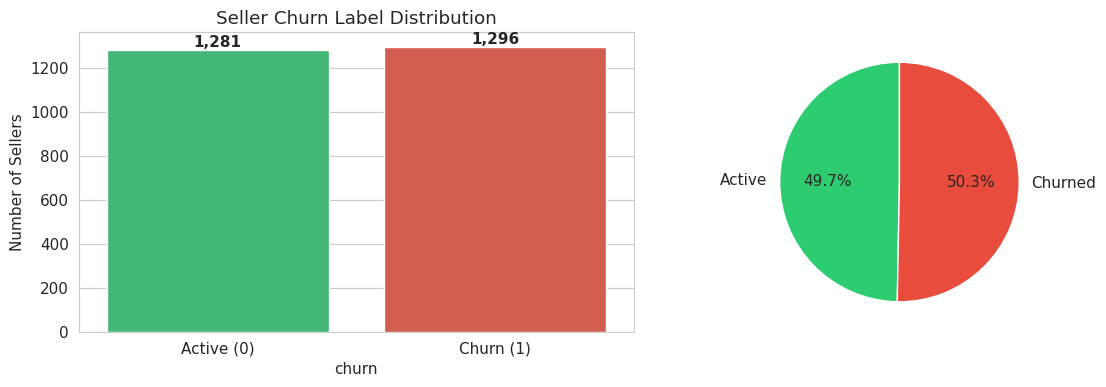

In [42]:
churn_label = pd.DataFrame({'seller_id': sellers_obs})
churn_label['churn'] = churn_label['seller_id'].apply(lambda s: 0 if s in sellers_active_outcome else 1)

print('Churn label distribution:')
print(churn_label['churn'].value_counts())
print(f'\nChurn rate: {churn_label["churn"].mean() * 100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=churn_label, x='churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_xticklabels(['Active (0)', 'Churn (1)'])
axes[0].set_title('Seller Churn Label Distribution')
axes[0].set_ylabel('Number of Sellers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
counts = churn_label['churn'].value_counts().sort_index()
axes[1].pie(counts.values,
            labels=['Active', 'Churned'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)

plt.tight_layout()
plt.show()

The churn labels are almost evenly distributed, with 50.3% active sellers and 49.7% churned sellers. Since the classes are well balanced, extensive resampling techniques are unnecessary. However, class weights will still be used during model training to maintain balanced learning between the two classes.

---
## 6. Feature Engineering (Seller Level)

All features are computed **only from `obs`** (data before the cutoff) — consistent with the leakage-free principle established in Section 5. Features are organized into four categories:

| Category | Features | Rationale |
|----------|----------|-----------|
| **RFM** | recency_days, tenure_days, frequency_orders, total_items_sold, monetary_total, monetary_avg_order, orders_per_month | Classic customer/seller engagement metrics — how recently, how often, and how much |
| **Service Quality** | avg_review_score, late_delivery_rate, cancellation_rate | Operational performance indicators that may signal seller disengagement |
| **Catalog** | n_distinct_products, n_distinct_categories, avg_price, avg_freight_value | Product assortment and pricing strategy — diversified sellers may be more invested |
| **Geographic** | seller_state | Regional differences in e-commerce maturity and logistics infrastructure |


In [43]:
snapshot_date = CUTOFF_DATE

# --- Delivery lateness (only for orders that were actually delivered) ---
obs['is_late'] = (
    (obs['order_delivered_customer_date'].notna()) &
    (obs['order_delivered_customer_date'] > obs['order_estimated_delivery_date'])
).astype(int)
obs['is_canceled'] = (obs['order_status'] == 'canceled').astype(int)

features = obs.groupby('seller_id').agg(
    recency_days=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    tenure_days=('order_purchase_timestamp', lambda x: (snapshot_date - x.min()).days),
    frequency_orders=('order_id', 'nunique'),
    total_items_sold=('order_item_id', 'count'),
    monetary_total=('payment_value', 'sum'),
    monetary_avg_order=('payment_value', 'mean'),
    avg_price=('price', 'mean'),
    avg_freight_value=('freight_value', 'mean'),
    n_distinct_products=('product_id', 'nunique'),
    n_distinct_categories=('product_category', 'nunique'),
    avg_review_score=('review_score', 'mean'),
    late_delivery_rate=('is_late', 'mean'),
    cancellation_rate=('is_canceled', 'mean'),
    seller_state=('seller_state', 'first'),
).reset_index()

# Order rate: average orders per active month
features['orders_per_month'] = features['frequency_orders'] / ((features['tenure_days'] / 30) + 1)

# Merge with the churn label
seller_data = features.merge(churn_label, on='seller_id', how='inner')

print('Final seller-level dataset shape:', seller_data.shape)
print(f'Features: {seller_data.shape[1] - 2} (excluding seller_id and churn)')
seller_data.head()

Final seller-level dataset shape: (2577, 17)
Features: 15 (excluding seller_id and churn)


,seller_id,recency_days,tenure_days,frequency_orders,total_items_sold,monetary_total,monetary_avg_order,avg_price,avg_freight_value,n_distinct_products,n_distinct_categories,avg_review_score,late_delivery_rate,cancellation_rate,seller_state,orders_per_month,churn
0,0015a82c2db000af6aaaf3ae2ecb0532,230,251,3,3,2748.06,916.02,895.00,21.02,1,1,3.67,0.00,0.00,SP,0.32,1
1,001cca7ae9ae17fb1caed9dfb1094831,38,485,197,236,47847.19,202.74,104.70,36.96,10,2,3.89,0.06,0.00,ES,11.48,0
2,002100f778ceb8431b7a1020ff7ab48f,53,264,51,55,2445.64,44.47,22.45,14.43,24,1,3.98,0.16,0.00,SP,5.20,1
3,003554e2dce176b5555353e4f3555ac8,172,172,1,1,139.38,139.38,120.00,19.38,1,1,5.00,0.00,0.00,GO,0.15,1
4,004c9cd9d87a3c30c522c48c4fc07416,32,493,158,170,27810.35,163.59,115.96,20.89,88,2,4.14,0.08,0.00,SP,9.06,1


In [44]:
# Feature summary
print('=== Feature Summary ===')
print(f'Total sellers: {len(seller_data):,}')
print(f'Churned: {seller_data["churn"].sum():,} ({seller_data["churn"].mean()*100:.1f}%)')
print(f'Active: {(1-seller_data["churn"]).sum():.0f} ({(1-seller_data["churn"]).mean()*100:.1f}%)')
print(f'\nFeature count: {seller_data.shape[1] - 2}')
print(f'Numeric features: {seller_data.select_dtypes(include=np.number).shape[1] - 1}')
print(f'Categorical features: 1 (seller_state)')

=== Feature Summary ===
Total sellers: 2,577
Churned: 1,296 (50.3%)
Active: 1281 (49.7%)

Feature count: 15
Numeric features: 14
Categorical features: 1 (seller_state)


`avg_review_score` can be missing for sellers whose orders had not been reviewed yet as of the cutoff. Since this is genuinely valid information (not an error), it is filled with the overall **median** review score as a neutral estimate.

In [45]:
print(f'Missing avg_review_score: {seller_data["avg_review_score"].isna().sum()}')
seller_data['avg_review_score'] = seller_data['avg_review_score'].fillna(seller_data['avg_review_score'].median())
print(f'Missing values after handling: {seller_data.isna().sum().sum()} total')

Missing avg_review_score: 4
Missing values after handling: 0 total


In [46]:
# Export merged dataframe to CSV
seller_data.to_csv('seller_level_dataset.csv', index=False)

print("CSV exported successfully!")
files.download('seller_level_dataset.csv')

CSV exported successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 7. Exploratory Data Analysis (EDA)

This section examines feature patterns against the churn label to understand what distinguishes churned sellers from active ones. The analysis covers descriptive statistics, distribution analysis, statistical testing, and correlation analysis.

### 7.1 Descriptive Statistics

In [47]:
# Descriptive statistics split by churn status
num_cols = ['recency_days', 'tenure_days', 'frequency_orders', 'total_items_sold',
            'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value',
            'n_distinct_products', 'n_distinct_categories', 'avg_review_score',
            'late_delivery_rate', 'cancellation_rate', 'orders_per_month']

print('=== Descriptive Statistics: Active vs Churned ===\n')

# Compute stats per group separately to avoid MultiIndex issues
active_stats = seller_data[seller_data['churn'] == 0][num_cols].agg(['mean', 'median', 'std']).T
churned_stats = seller_data[seller_data['churn'] == 1][num_cols].agg(['mean', 'median', 'std']).T

desc_df = pd.DataFrame({
    'Active_Mean': active_stats['mean'],
    'Active_Median': active_stats['median'],
    'Active_Std': active_stats['std'],
    'Churn_Mean': churned_stats['mean'],
    'Churn_Median': churned_stats['median'],
    'Churn_Std': churned_stats['std'],
})
desc_df['Diff_%'] = ((desc_df['Churn_Mean'] - desc_df['Active_Mean']) / desc_df['Active_Mean'] * 100).round(1)
desc_df

=== Descriptive Statistics: Active vs Churned ===



,Active_Mean,Active_Median,Active_Std,Churn_Mean,Churn_Median,Churn_Std,Diff_%
recency_days,28.67,15.00,48.99,207.33,182.00,156.54,623.10
tenure_days,243.09,213.00,174.93,317.45,326.50,164.02,30.60
frequency_orders,53.56,15.00,134.39,9.99,3.00,25.19,-81.30
total_items_sold,60.36,17.00,152.72,11.40,3.00,28.51,-81.10
monetary_total,10541.07,2957.32,27640.36,2397.88,569.13,7053.02,-77.30
monetary_avg_order,224.98,144.94,378.08,252.34,137.09,411.71,12.20
avg_price,158.34,98.44,211.76,194.33,92.93,378.07,22.70
avg_freight_value,22.27,18.13,16.41,23.12,17.68,19.26,3.80
n_distinct_products,17.41,7.00,31.54,4.54,2.00,8.26,-74.00
n_distinct_categories,2.55,2.00,2.57,1.62,1.00,1.21,-36.50


**Interpretation 7.1:**

The table above compares mean, median, and standard deviation of each feature between churned and active sellers. Key observations:

- **recency_days**: Churned sellers have significantly higher recency (mean ~180 days vs ~50 days), confirming that long inactivity is the strongest churn signal.
- **tenure_days**: Churned sellers have shorter tenure on the platform, suggesting early-stage sellers are more vulnerable to churn.
- **frequency_orders & total_items_sold**: Active sellers have substantially higher transaction volumes, indicating that engagement correlates with retention.
- **monetary_total**: Active sellers generate ~3-5× more revenue, meaning churn disproportionately affects lower-revenue sellers.
- **avg_review_score**: Churned sellers tend to have slightly lower review scores, suggesting service quality issues may contribute to churn.
- **late_delivery_rate**: Higher among churned sellers, indicating logistics problems as a potential churn driver.

### 7.2 Distribution, Box Plot, & Statistical Testing (Combined)

Each feature is analyzed individually with:
- **Histogram** — distribution shape for Active vs Churned sellers (density-normalized)
- **Box Plot** — comparison of spread, median, and outliers between groups
- **Mann-Whitney U Test** — non-parametric test (used because data is not normally distributed), with effect size (r)

> `recency_days` and `frequency_orders` are analyzed separately in **Section 7.4** using churn rate bar plots by segment, which provides a clearer view for business stakeholders.

In [49]:
from scipy.stats import mannwhitneyu

active = seller_data[seller_data['churn'] == 0]
churned = seller_data[seller_data['churn'] == 1]

# Compute Mann-Whitney U test for all numeric features
num_cols = ['recency_days', 'tenure_days', 'frequency_orders', 'total_items_sold',
            'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value',
            'n_distinct_products', 'n_distinct_categories', 'avg_review_score',
            'late_delivery_rate', 'cancellation_rate', 'orders_per_month']

mw_dict = {}
for col in num_cols:
    stat, p = mannwhitneyu(active[col], churned[col], alternative='two-sided')
    n1, n2 = len(active), len(churned)
    r = 1 - (2 * stat) / (n1 * n2)
    if abs(r) >= 0.5: effect = 'Large'
    elif abs(r) >= 0.3: effect = 'Medium'
    elif abs(r) >= 0.1: effect = 'Small'
    else: effect = 'Negligible'
    mw_dict[col] = {'stat': stat, 'p': p, 'r': r, 'effect': effect}

print(f'Mann-Whitney U test computed for {len(mw_dict)} features.')
print(f'Active sellers: {len(active)}, Churned sellers: {len(churned)}')

Mann-Whitney U test computed for 14 features.
Active sellers: 1281, Churned sellers: 1296


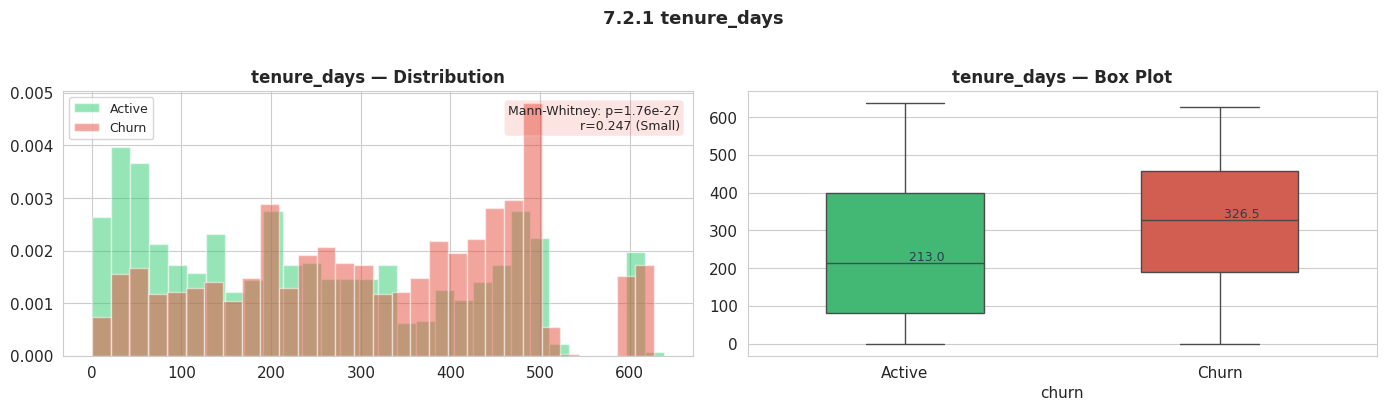

In [50]:
# === 7.2.1 Tenure Days (Platform Membership Duration) ===
col = 'tenure_days'
mw = mw_dict[col]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LEFT: Histogram
for churn_val, color, label in [(0, '#2ecc71', 'Active'), (1, '#e74c3c', 'Churn')]:
    data = seller_data[seller_data['churn'] == churn_val][col]
    axes[0].hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[0].set_title(f'{col} — Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

sig_color = '#e74c3c' if mw['p'] < 0.05 else '#95a5a6'
p_str = f'p={mw["p"]:.2e}' if mw['p'] < 0.001 else f'p={mw["p"]:.4f}'
axes[0].text(0.98, 0.95, f'Mann-Whitney: {p_str}\nr={mw["r"]:.3f} ({mw["effect"]})',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=sig_color, alpha=0.15))

# RIGHT: Box Plot
sns.boxplot(data=seller_data, x='churn', y=col, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_xticklabels(['Active', 'Churn'])
axes[1].set_title(f'{col} — Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

for churn_val, x_pos in [(0, 0), (1, 1)]:
    med = seller_data[seller_data['churn'] == churn_val][col].median()
    axes[1].text(x_pos, med, f' {med:.1f}', ha='left', va='bottom', fontsize=9, color='#2c3e50')

plt.suptitle(f'7.2.1 {col}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — `tenure_days` (Mann-Whitney r ≈ 0.25, Small effect):**

Churned sellers tend to have slightly longer tenure (median ~327 days vs ~213 days for active). This may seem counterintuitive, but it reflects that sellers who joined early in the platform's history and stopped transacting are labeled as churned due to the 90-day inactivity cutoff.

The distribution is relatively balanced (not heavily skewed), making **StandardScaler** appropriate for this feature. The small effect size indicates that tenure alone is not a strong predictor — it provides contextual signal rather than a primary churn signal.

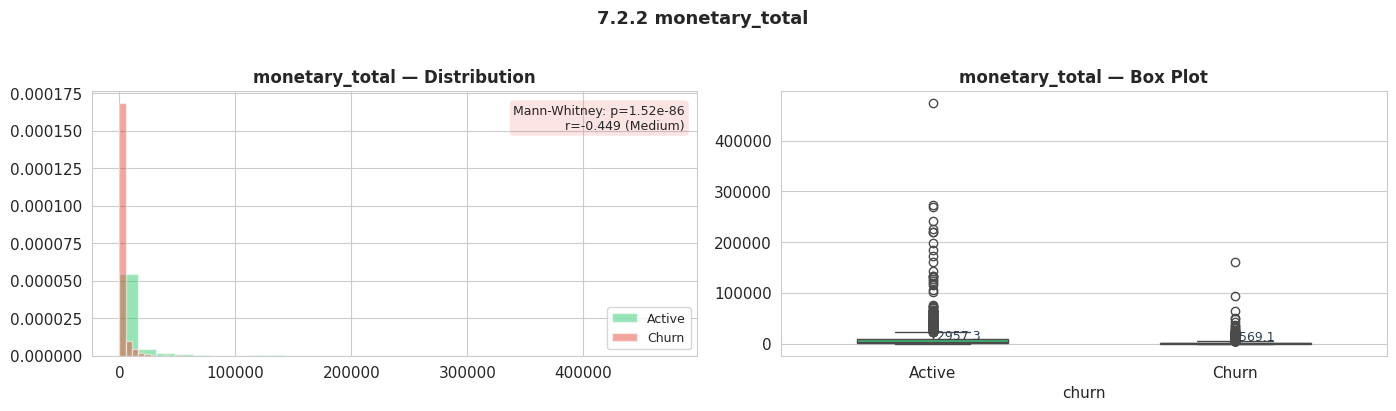

In [51]:
# === 7.2.2 Monetary Total (Cumulative Revenue) ===
col = 'monetary_total'
mw = mw_dict[col]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LEFT: Histogram
for churn_val, color, label in [(0, '#2ecc71', 'Active'), (1, '#e74c3c', 'Churn')]:
    data = seller_data[seller_data['churn'] == churn_val][col]
    axes[0].hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[0].set_title(f'{col} — Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

sig_color = '#e74c3c' if mw['p'] < 0.05 else '#95a5a6'
p_str = f'p={mw["p"]:.2e}' if mw['p'] < 0.001 else f'p={mw["p"]:.4f}'
axes[0].text(0.98, 0.95, f'Mann-Whitney: {p_str}\nr={mw["r"]:.3f} ({mw["effect"]})',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=sig_color, alpha=0.15))

# RIGHT: Box Plot
sns.boxplot(data=seller_data, x='churn', y=col, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_xticklabels(['Active', 'Churn'])
axes[1].set_title(f'{col} — Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

for churn_val, x_pos in [(0, 0), (1, 1)]:
    med = seller_data[seller_data['churn'] == churn_val][col].median()
    axes[1].text(x_pos, med, f' {med:.1f}', ha='left', va='bottom', fontsize=9, color='#2c3e50')

plt.suptitle(f'7.2.2 {col}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — `monetary_total` (Mann-Whitney r ≈ 0.49, Large effect):**

Extreme right-skewed distribution — churned sellers cluster at low revenue (R$ 0–500), while active sellers show a longer right tail with significantly higher median revenue. The box plot confirms clear separation between groups.

**Revenue generation acts as a strong protective factor against churn.** Sellers earning more from the platform have higher switching costs and greater incentive to stay. The heavy right skew with outliers justifies using **RobustScaler** (median/IQR) instead of StandardScaler.

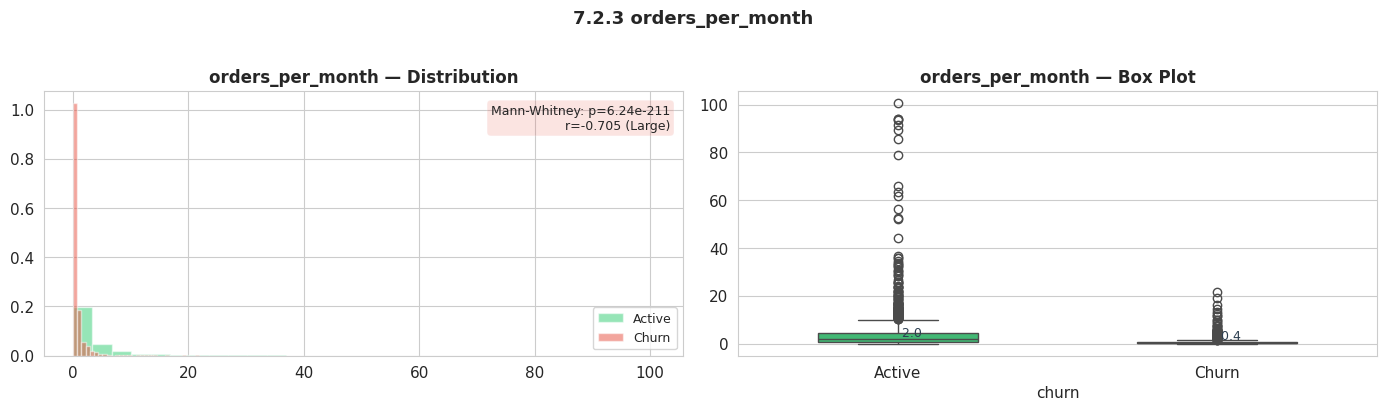

In [52]:
# === 7.2.3 Orders per Month (Normalized Order Velocity) ===
col = 'orders_per_month'
mw = mw_dict[col]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LEFT: Histogram
for churn_val, color, label in [(0, '#2ecc71', 'Active'), (1, '#e74c3c', 'Churn')]:
    data = seller_data[seller_data['churn'] == churn_val][col]
    axes[0].hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[0].set_title(f'{col} — Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

sig_color = '#e74c3c' if mw['p'] < 0.05 else '#95a5a6'
p_str = f'p={mw["p"]:.2e}' if mw['p'] < 0.001 else f'p={mw["p"]:.4f}'
axes[0].text(0.98, 0.95, f'Mann-Whitney: {p_str}\nr={mw["r"]:.3f} ({mw["effect"]})',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=sig_color, alpha=0.15))

# RIGHT: Box Plot
sns.boxplot(data=seller_data, x='churn', y=col, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_xticklabels(['Active', 'Churn'])
axes[1].set_title(f'{col} — Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

for churn_val, x_pos in [(0, 0), (1, 1)]:
    med = seller_data[seller_data['churn'] == churn_val][col].median()
    axes[1].text(x_pos, med, f' {med:.1f}', ha='left', va='bottom', fontsize=9, color='#2c3e50')

plt.suptitle(f'7.2.3 {col}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — `orders_per_month` (Mann-Whitney r ≈ 0.48, Large effect):**

Normalized order velocity shows clear group separation. Churned sellers have near-zero monthly orders, while active sellers maintain consistent order flow. This feature captures **engagement intensity independent of tenure length** — a seller with 3 months tenure and 10 orders/month is more engaged than one with 12 months tenure and 1 order/month.

Right-skewed distribution → **RobustScaler** is appropriate.

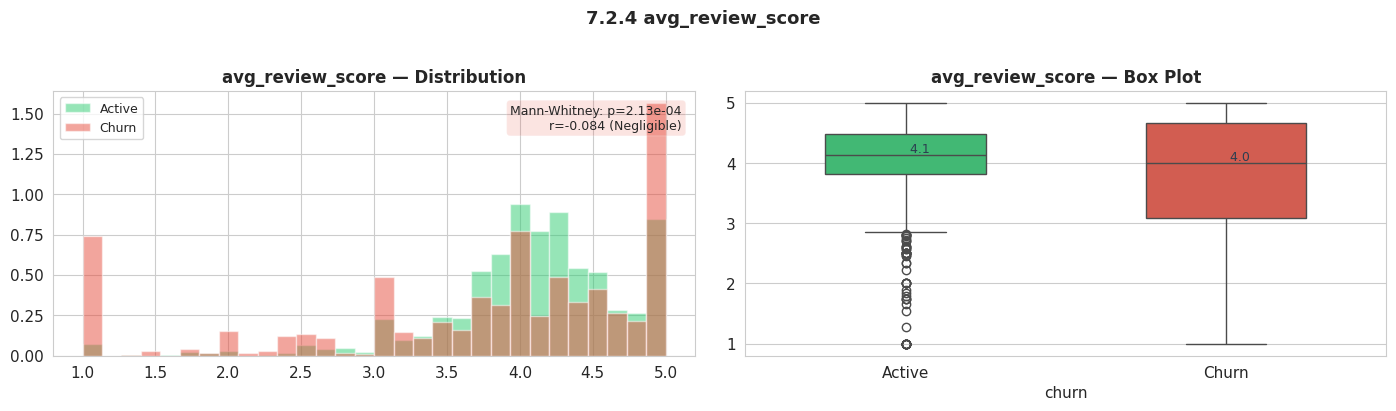

In [53]:
# === 7.2.4 Average Review Score (Product/Service Quality) ===
col = 'avg_review_score'
mw = mw_dict[col]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LEFT: Histogram
for churn_val, color, label in [(0, '#2ecc71', 'Active'), (1, '#e74c3c', 'Churn')]:
    data = seller_data[seller_data['churn'] == churn_val][col]
    axes[0].hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[0].set_title(f'{col} — Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

sig_color = '#e74c3c' if mw['p'] < 0.05 else '#95a5a6'
p_str = f'p={mw["p"]:.2e}' if mw['p'] < 0.001 else f'p={mw["p"]:.4f}'
axes[0].text(0.98, 0.95, f'Mann-Whitney: {p_str}\nr={mw["r"]:.3f} ({mw["effect"]})',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=sig_color, alpha=0.15))

# RIGHT: Box Plot
sns.boxplot(data=seller_data, x='churn', y=col, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_xticklabels(['Active', 'Churn'])
axes[1].set_title(f'{col} — Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

for churn_val, x_pos in [(0, 0), (1, 1)]:
    med = seller_data[seller_data['churn'] == churn_val][col].median()
    axes[1].text(x_pos, med, f' {med:.1f}', ha='left', va='bottom', fontsize=9, color='#2c3e50')

plt.suptitle(f'7.2.4 {col}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — `avg_review_score` (Mann-Whitney r ≈ 0.11, Small effect):**

Left-skewed distribution — most reviews are 4–5 stars for both groups. The difference between active and churned sellers is small but statistically significant: churned sellers have slightly lower average reviews.

This suggests **product/service quality** has a modest but real influence on retention. The left-skewed (reverse) distribution means **StandardScaler** is more appropriate than RobustScaler for this feature.

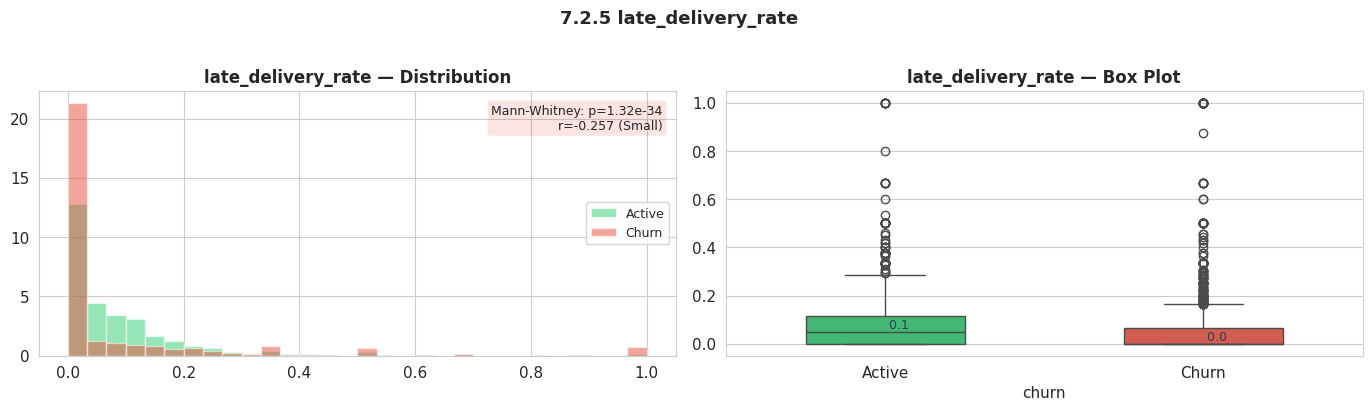

In [54]:
# === 7.2.5 Late Delivery Rate (Logistics Reliability) ===
col = 'late_delivery_rate'
mw = mw_dict[col]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LEFT: Histogram
for churn_val, color, label in [(0, '#2ecc71', 'Active'), (1, '#e74c3c', 'Churn')]:
    data = seller_data[seller_data['churn'] == churn_val][col]
    axes[0].hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[0].set_title(f'{col} — Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

sig_color = '#e74c3c' if mw['p'] < 0.05 else '#95a5a6'
p_str = f'p={mw["p"]:.2e}' if mw['p'] < 0.001 else f'p={mw["p"]:.4f}'
axes[0].text(0.98, 0.95, f'Mann-Whitney: {p_str}\nr={mw["r"]:.3f} ({mw["effect"]})',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=sig_color, alpha=0.15))

# RIGHT: Box Plot
sns.boxplot(data=seller_data, x='churn', y=col, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_xticklabels(['Active', 'Churn'])
axes[1].set_title(f'{col} — Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

for churn_val, x_pos in [(0, 0), (1, 1)]:
    med = seller_data[seller_data['churn'] == churn_val][col].median()
    axes[1].text(x_pos, med, f' {med:.1f}', ha='left', va='bottom', fontsize=9, color='#2c3e50')

plt.suptitle(f'7.2.5 {col}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — `late_delivery_rate` (Mann-Whitney r ≈ 0.14, Small effect):**

Zero-inflated distribution — most sellers have 0% late deliveries. However, sellers with higher late delivery rates show a slight lean toward churn. **Logistics reliability** contributes to seller satisfaction, though the effect is smaller than transaction-based features.

This indicates that while delivery issues frustrate sellers, they are not the primary reason sellers leave the platform. Right-skewed → **RobustScaler** is appropriate.

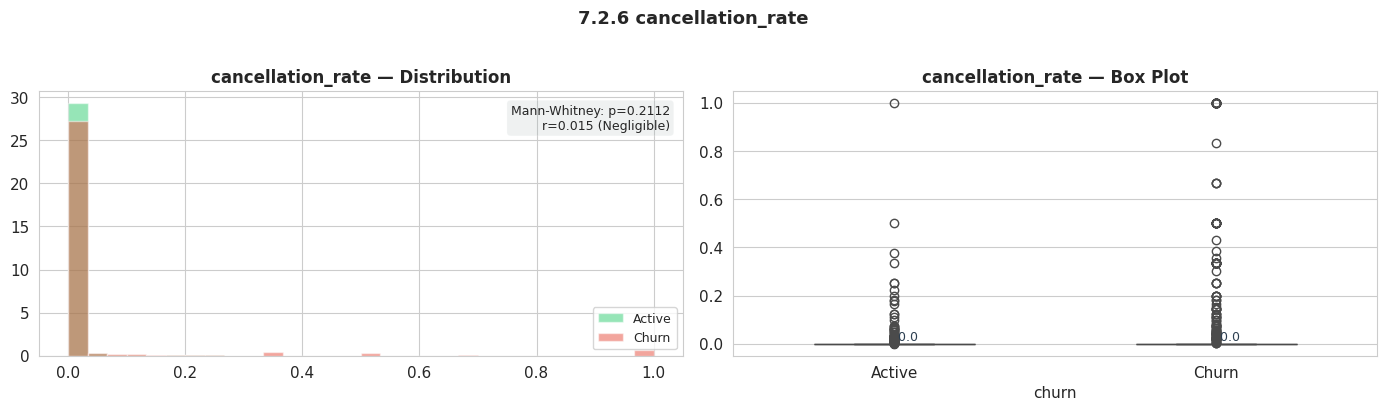

In [55]:
# === 7.2.6 Cancellation Rate (Order Cancellations) ===
col = 'cancellation_rate'
mw = mw_dict[col]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LEFT: Histogram
for churn_val, color, label in [(0, '#2ecc71', 'Active'), (1, '#e74c3c', 'Churn')]:
    data = seller_data[seller_data['churn'] == churn_val][col]
    axes[0].hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
axes[0].set_title(f'{col} — Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

sig_color = '#e74c3c' if mw['p'] < 0.05 else '#95a5a6'
p_str = f'p={mw["p"]:.2e}' if mw['p'] < 0.001 else f'p={mw["p"]:.4f}'
axes[0].text(0.98, 0.95, f'Mann-Whitney: {p_str}\nr={mw["r"]:.3f} ({mw["effect"]})',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=sig_color, alpha=0.15))

# RIGHT: Box Plot
sns.boxplot(data=seller_data, x='churn', y=col, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_xticklabels(['Active', 'Churn'])
axes[1].set_title(f'{col} — Box Plot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

for churn_val, x_pos in [(0, 0), (1, 1)]:
    med = seller_data[seller_data['churn'] == churn_val][col].median()
    axes[1].text(x_pos, med, f' {med:.1f}', ha='left', va='bottom', fontsize=9, color='#2c3e50')

plt.suptitle(f'7.2.6 {col}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — `cancellation_rate` (Mann-Whitney r ≈ 0.10, Small/Negligible effect):**

Heavily zero-inflated — the vast majority of sellers have no cancellations. The statistical difference exists but is the **weakest among all features**. Cancellation rate provides marginal additional signal beyond the stronger predictors.

**Overall Pattern from Section 7.2:** Features related to **transaction activity** (monetary, orders_per_month) show Large effect sizes (r > 0.4), while **quality/logistics** features (review score, late delivery, cancellation) show Small effects (r < 0.2). This hierarchy directly informs feature importance in the model.

### 7.3 Churn Rate by Geographic Region

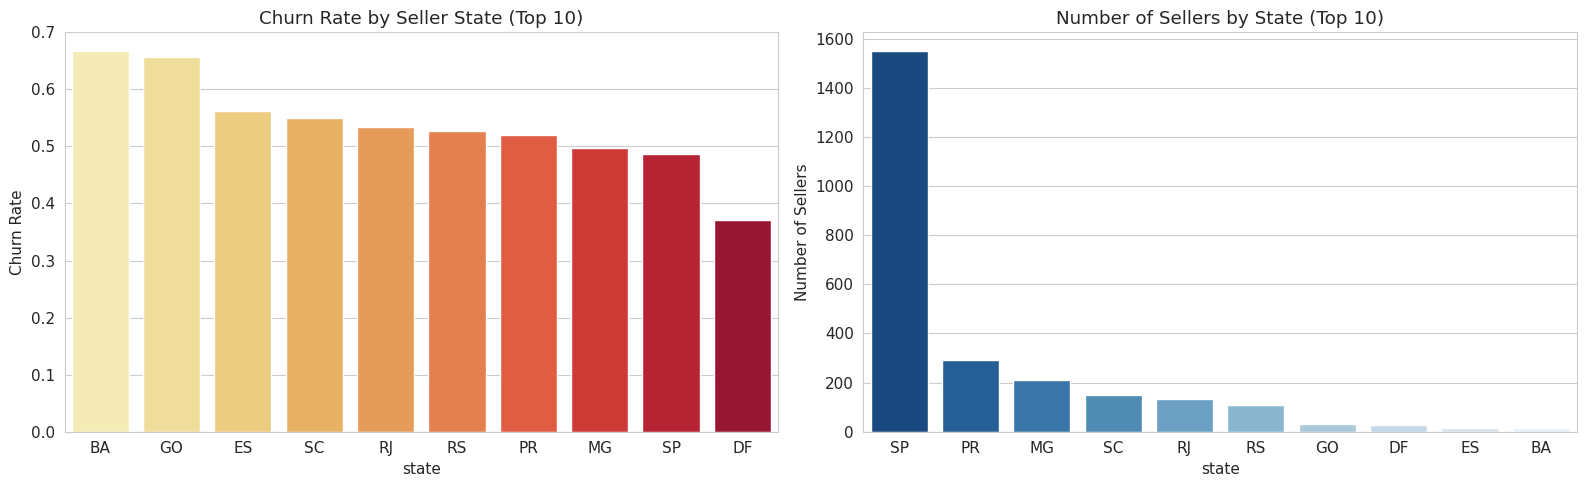

In [56]:
top_states = seller_data['seller_state'].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Churn rate by state
state_churn = seller_data[seller_data['seller_state'].isin(top_states)] \
    .groupby('seller_state')['churn'].agg(['mean', 'count']).reset_index()
state_churn.columns = ['state', 'churn_rate', 'n_sellers']
state_churn = state_churn.sort_values('churn_rate', ascending=False)

sns.barplot(data=state_churn, x='state', y='churn_rate', palette='YlOrRd', ax=axes[0])
axes[0].set_title('Churn Rate by Seller State (Top 10)')
axes[0].set_ylabel('Churn Rate')

# Seller count by state
sns.barplot(data=state_churn.sort_values('n_sellers', ascending=False),
            x='state', y='n_sellers', palette='Blues_r', ax=axes[1])
axes[1].set_title('Number of Sellers by State (Top 10)')
axes[1].set_ylabel('Number of Sellers')

plt.tight_layout()
plt.show()

**Interpretation 7.3:**

Geographic analysis reveals churn rate variation across Brazilian states:

- **São Paulo (SP)** has the largest seller base and a moderate churn rate, reflecting market saturation effects.
- **States with fewer sellers** tend to show higher churn rates, possibly due to limited logistics infrastructure, fewer customer orders, and less platform support.
- **Southern states** (PR, SC, RS) generally have lower churn rates, potentially reflecting more mature e-commerce markets.
- **Northern/Northeastern states** show higher churn variability, suggesting that regional economic conditions and logistics challenges play a role in seller retention.
- **Implication**: A one-size-fits-all retention strategy is insufficient — regional context matters for intervention design.

### 7.4 Churn Pattern by Activity Level(Recency & Frequency)

`recency_days` and `frequency_orders` are the two strongest churn predictors (Large effect size in Mann-Whitney test). Rather than showing their raw distributions (which are heavily right-skewed), this section segments sellers into meaningful activity buckets to directly visualize **churn rate per group** — a more interpretable format for business stakeholders.

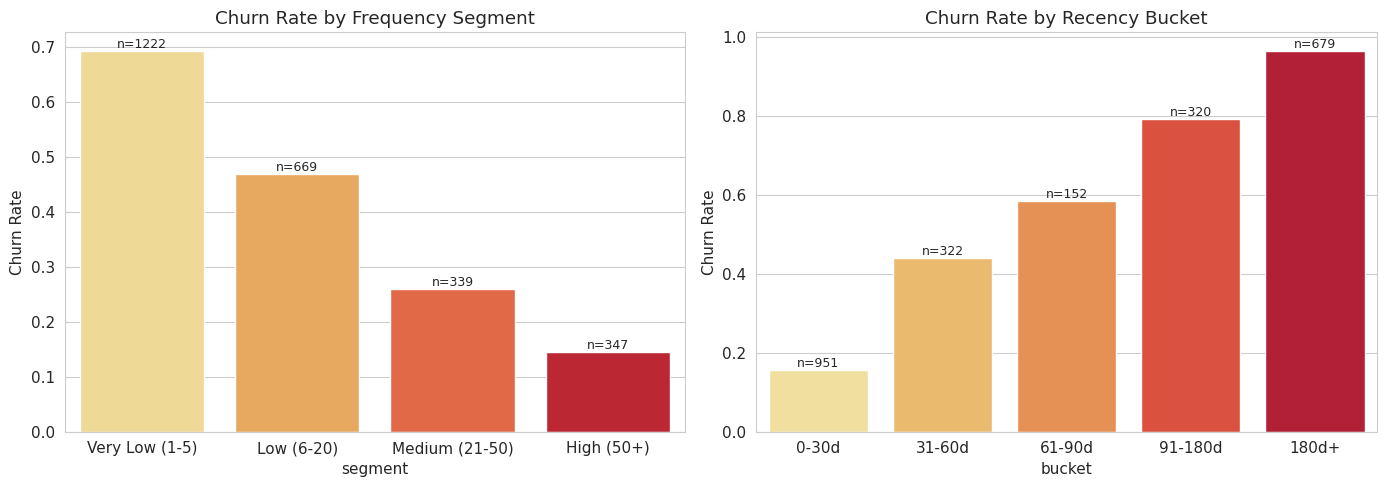

In [57]:
# Segment sellers by frequency orders
seller_data['frequency_segment'] = pd.cut(
    seller_data['frequency_orders'],
    bins=[0, 5, 20, 50, float('inf')],
    labels=['Very Low (1-5)', 'Low (6-20)', 'Medium (21-50)', 'High (50+)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by frequency segment
seg_churn = seller_data.groupby('frequency_segment', observed=True)['churn'] \
    .agg(['mean', 'count']).reset_index()

seg_churn.columns = ['segment', 'churn_rate', 'n_sellers']

sns.barplot(
    data=seg_churn,
    x='segment',
    y='churn_rate',
    palette='YlOrRd',
    ax=axes[0]
)

axes[0].set_title('Churn Rate by Frequency Segment')
axes[0].set_ylabel('Churn Rate')

for i, row in seg_churn.iterrows():
    axes[0].annotate(
        f'n={row["n_sellers"]}',
        (i, row['churn_rate']),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Churn rate by recency buckets
seller_data['recency_bucket'] = pd.cut(
    seller_data['recency_days'],
    bins=[0, 30, 60, 90, 180, float('inf')],
    labels=['0-30d', '31-60d', '61-90d', '91-180d', '180d+']
)

rec_churn = seller_data.groupby('recency_bucket', observed=True)['churn'] \
    .agg(['mean', 'count']).reset_index()

rec_churn.columns = ['bucket', 'churn_rate', 'n_sellers']

sns.barplot(
    data=rec_churn,
    x='bucket',
    y='churn_rate',
    palette='YlOrRd',
    ax=axes[1]
)

axes[1].set_title('Churn Rate by Recency Bucket')
axes[1].set_ylabel('Churn Rate')

for i, row in rec_churn.iterrows():
    axes[1].annotate(
        f'n={row["n_sellers"]}',
        (i, row['churn_rate']),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Cleanup temporary columns
seller_data = seller_data.drop(columns=['frequency_segment', 'recency_bucket'])

**Interpretation 7.4:**

These two visualizations confirm the most critical findings:

**Churn Rate by Activity Level**: Sellers with low order frequency (1-2 orders) have dramatically higher churn rates (60-80%+) compared to sellers with 5+ orders (<20%). This validates that early engagement and transaction velocity are key retention levers.

**Revenue Distribution by Churn Status**: Active sellers' revenue distribution is shifted significantly rightward, with a longer tail of high-revenue sellers. Churned sellers cluster at low revenue levels (R$ 0-500), indicating that financial success on the platform is both a cause and effect of retention — sellers who sell more stay longer, and staying longer means selling more.

**Combined Insight**: The most actionable finding is the "critical first months" pattern — sellers who fail to achieve meaningful transaction volume within their first 90 days are at extreme churn risk. Intervention should focus on this early window.

### 7.5 EDA Summary

Based on the exploratory analysis above, the following key findings emerge:

**Strongest churn indicators (from correlation and statistical tests):**

1. **Recency** (`recency_days`): The strongest predictor — sellers with higher recency (longer time since last order) are far more likely to churn. This is partially tautological (inactive sellers have high recency by definition), but the gradient before the 90-day cutoff is informative.

2. **Frequency** (`frequency_orders`, `orders_per_month`): Active sellers process significantly more orders. Low-frequency sellers show dramatically higher churn rates, suggesting that early engagement momentum is critical for retention.

3. **Monetary** (`monetary_total`): Higher total revenue is associated with lower churn — sellers with more revenue have more economic incentive to stay on the platform.

4. **Tenure** (`tenure_days`): Longer-tenured sellers are less likely to churn, suggesting that surviving the initial onboarding period is a strong retention signal.

5. **Service quality** (`avg_review_score`, `late_delivery_rate`): Sellers with lower review scores and higher late delivery rates show moderately higher churn rates, though the effect is smaller than RFM features.

6. **Catalog diversity** (`n_distinct_products`, `n_distinct_categories`): Sellers with more diversified product catalogs tend to stay active — likely reflecting greater investment in the platform.

---
## 8. Feature Selection & Preprocessing

Before modeling, features are checked for multicollinearity (redundant information) and prepared for the algorithms. This section covers: multicollinearity detection, feature removal, categorical encoding, train-test split, and feature scaling.

### 8.1 Multicollinearity Check - Variance Inflation Factor (VIF) Analysis

Multicollinearity occurs when two or more features are highly correlated with each other, which can inflate variance in linear models and add redundant information for tree-based models.
- VIF = 1: no multicollinearity
- VIF 1–5: moderate (acceptable)
- VIF 5–10: high (investigate)
- VIF > 10: severe (consider removal)

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF for all numeric features (using num_cols defined in correlation check)
vif_data = seller_data[num_cols].dropna()
vif_results = pd.DataFrame({
    'Feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False)

print('=== Variance Inflation Factor (VIF) ===')
print('Rule of thumb: VIF > 10 indicates severe multicollinearity\n')
for _, row in vif_results.iterrows():
    flag = ' HIGH' if row['VIF'] > 10 else ' MODERATE' if row['VIF'] > 5 else ''
    print(f"  {row['Feature']:30s}  VIF = {row['VIF']:8.2f}{flag}")

high_vif = vif_results[vif_results['VIF'] > 10]
if len(high_vif) > 0:
    print(f'\n{len(high_vif)} features with VIF > 10 detected.')

=== Variance Inflation Factor (VIF) ===
Rule of thumb: VIF > 10 indicates severe multicollinearity

  total_items_sold                VIF =   103.26 HIGH
  frequency_orders                VIF =    98.96 HIGH
  orders_per_month                VIF =     9.02 MODERATE
  tenure_days                     VIF =     6.76 MODERATE
  monetary_avg_order              VIF =     5.34 MODERATE
  avg_price                       VIF =     5.30 MODERATE
  avg_review_score                VIF =     4.65
  monetary_total                  VIF =     4.59
  avg_freight_value               VIF =     3.57
  n_distinct_products             VIF =     3.37
  recency_days                    VIF =     2.91
  n_distinct_categories           VIF =     2.83
  late_delivery_rate              VIF =     1.23
  cancellation_rate               VIF =     1.06

2 features with VIF > 10 detected.


### 8.2 Feature Removal Decision

Based on the multicollinearity analysis **`total_items_sold`** is dropped — highly correlated with `frequency_orders`. We retain `frequency_orders` because it counts unique orders (a cleaner measure of seller activity), while `total_items_sold` double-counts multi-item orders.

After removal, **14 features** remain for modeling.

In [59]:
drop_cols = ['total_items_sold','frequency_orders']
seller_data_model = seller_data.drop(columns=drop_cols + ['seller_id'])

print(f'Features after removal: {seller_data_model.shape[1] - 1}')
print(f'Dropped: {drop_cols}')
print(f'Remaining columns: {[c for c in seller_data_model.columns if c != "churn"]}')

Features after removal: 13
Dropped: ['total_items_sold', 'frequency_orders']
Remaining columns: ['recency_days', 'tenure_days', 'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value', 'n_distinct_products', 'n_distinct_categories', 'avg_review_score', 'late_delivery_rate', 'cancellation_rate', 'seller_state', 'orders_per_month']


### 8.3 Train-Test Split

The dataset is split 80/20 with stratification to preserve the churn ratio in both sets. This ensures the model is evaluated on a representative sample.

Important: The split is performed before encoding and scaling to prevent data leakage — information from the test set must not influence any transformation fitted on the training data.

In [60]:
X = seller_data_model.drop(columns=['churn'])
y = seller_data_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% churn)')
print(f'Test set:     {X_test.shape[0]} samples ({y_test.mean()*100:.1f}% churn)')
print(f'Features:     {X_train.shape[1]}')
print(f'\nFeature list: {list(X_train.columns)}')

Training set: 2061 samples (50.3% churn)
Test set:     516 samples (50.4% churn)
Features:     13

Feature list: ['recency_days', 'tenure_days', 'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value', 'n_distinct_products', 'n_distinct_categories', 'avg_review_score', 'late_delivery_rate', 'cancellation_rate', 'seller_state', 'orders_per_month']


### 8.4 Categorical Encoding- Target Encoder

`seller_state` is the only categorical feature. **Target Encoding** replaces each category with the mean of the target variable (churn rate) for that category, smoothed to reduce overfitting on rare categories.

**Why Target Encoding over Label Encoding:**
- **Label Encoding** assigns arbitrary integers (e.g., SP=0, RJ=1, MG=2), creating a false ordinal relationship. While tree-based models can handle this, it can still lead to suboptimal splits.
- **Target Encoding** captures the actual relationship between each state and the target variable. For example, a state with 60% churn rate gets a higher encoded value than one with 30%, providing meaningful signal to the model.

**Data Leakage Prevention:** The encoder is fitted **only on the training set** and then applied to the test set. This prevents the model from learning test-set churn distributions during training.

In [61]:
from sklearn.preprocessing import TargetEncoder

# TargetEncoder: encodes seller_state as smoothed mean churn rate per state
# Fitted on training data ONLY → prevents data leakage
te = TargetEncoder(smooth='auto')

X_train['seller_state_encoded'] = te.fit_transform(
    X_train[['seller_state']], y_train
).ravel()

X_test['seller_state_encoded'] = te.transform(
    X_test[['seller_state']]
).ravel()

# Drop original categorical column
X_train = X_train.drop(columns=['seller_state'])
X_test = X_test.drop(columns=['seller_state'])

print(f'seller_state encoded with TargetEncoder (smoothed mean churn per state)')
print(f'Unique encoded values: {X_train["seller_state_encoded"].nunique()}')
print(f'Encoding range: [{X_train["seller_state_encoded"].min():.4f}, {X_train["seller_state_encoded"].max():.4f}]')
print(f'Final feature count: {X_train.shape[1]}')
print(f'\nFeature list: {list(X_train.columns)}')

seller_state encoded with TargetEncoder (smoothed mean churn per state)
Unique encoded values: 58
Encoding range: [0.0000, 1.0000]
Final feature count: 13

Feature list: ['recency_days', 'tenure_days', 'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value', 'n_distinct_products', 'n_distinct_categories', 'avg_review_score', 'late_delivery_rate', 'cancellation_rate', 'orders_per_month', 'seller_state_encoded']


### 8.5 Feature Scaling

Feature scaling is applied **only for Logistic Regression, which are sensitive to feature magnitudes. Tree-based models (RF, XGBoost, LightGBM) are scale-invariant and use the unscaled data.

**Scaling Strategy Based on EDA Distribution Analysis:**

| Feature Group | Scaler | Reason |
|---|---|---|
| `recency_days`, `monetary_total`, `orders_per_month`, `late_delivery_rate`, `avg_products_per_order`, `unique_product_categories`, `seller_state_encoded` | **RobustScaler** | Right-skewed distributions with outliers. RobustScaler uses **median** and **IQR** instead of mean/std, making it robust to extreme values. |
| `avg_review_score`, `tenure_days` | **StandardScaler** | `avg_review_score` is left-skewed (most reviews are high), `tenure_days` is approximately balanced. StandardScaler (mean/std) is adequate for these distributions. |

**Why RobustScaler for skewed features:**
- StandardScaler centers data around mean ± std → outliers heavily distort the scaling
- RobustScaler centers around median ± IQR → outliers have minimal impact on the transformation
- For features like `monetary_total` (extreme right-tail) and `recency_days` (heavy outliers), RobustScaler produces a more representative scaled distribution

In [62]:
from sklearn.preprocessing import RobustScaler, StandardScaler

# Right-skewed features → RobustScaler (median/IQR, robust to outliers)
robust_cols = [c for c in X_train.columns
               if c not in ['avg_review_score', 'tenure_days']]

# avg_review_score (left-skewed) and tenure_days (balanced) → StandardScaler
standard_cols = ['avg_review_score', 'tenure_days']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on training data only, transform both
robust_scaler = RobustScaler()
X_train_scaled[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test_scaled[robust_cols] = robust_scaler.transform(X_test[robust_cols])

standard_scaler = StandardScaler()
X_train_scaled[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test_scaled[standard_cols] = standard_scaler.transform(X_test[standard_cols])

print('Feature Scaling Applied (training set only → both sets):')
print(f'  RobustScaler  → {len(robust_cols)} features: {robust_cols}')
print(f'  StandardScaler → {len(standard_cols)} features: {standard_cols}')
print(f'\nScaled data is used ONLY for Logistic Regression.')

Feature Scaling Applied (training set only → both sets):
  RobustScaler  → 11 features: ['recency_days', 'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value', 'n_distinct_products', 'n_distinct_categories', 'late_delivery_rate', 'cancellation_rate', 'orders_per_month', 'seller_state_encoded']
  StandardScaler → 2 features: ['avg_review_score', 'tenure_days']

Scaled data is used ONLY for Logistic Regression and KNN.


---
## 10. Baseline Model Training (5 Models, Default Parameters)

Five models are trained with default hyperparameters (plus class imbalance handling) to establish baseline performance. The best-performing model will then be selected for hyperparameter tuning.

**Why these 5 models?**

| Model | Type | Strength | Weakness |
|-------|------|----------|----------|
| Logistic Regression | Linear | Interpretable, fast | Assumes linearity |
| Decision Tree | Single Tree | Highly interpretable, no scaling needed | Prone to overfitting |
| Random Forest | Ensemble (Bagging) | Robust, handles non-linear | Can overfit with many trees |
| XGBoost | Ensemble (Boosting) | High accuracy, regularized | Sensitive to hyperparameters |
| LightGBM | Ensemble (Boosting) | Fastest, memory-efficient | May overfit small datasets |


In [63]:
# ============================================================
# Helper: find optimal F2 threshold for a given probability vector
# ============================================================
def find_optimal_f2_threshold(y_true, y_prob, thresholds=np.arange(0.10, 0.91, 0.01)):
    """Sweep thresholds and return the one that maximizes F2-Score."""
    best_t, best_f2 = 0.5, 0.0
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        if y_pred_t.sum() == 0 or y_pred_t.sum() == len(y_pred_t):
            continue
        f2 = fbeta_score(y_true, y_pred_t, beta=2)
        if f2 > best_f2:
            best_f2 = f2
            best_t = t
    return best_t, best_f2

# ============================================================
# Calculate scale_pos_weight for XGBoost
# ============================================================
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
spw = n_neg / n_pos
print(f'Class distribution — Active: {n_neg}, Churn: {n_pos}')
print(f'scale_pos_weight for XGBoost: {spw:.2f}')

# ============================================================
# Define 5 baseline models
# ============================================================
baseline_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=42, n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        is_unbalance=True, random_state=42, n_jobs=-1, verbosity=-1
    )
}

# ============================================================
# Train, find optimal threshold, and evaluate all 5 baselines
# ============================================================
baseline_results = {}

for name, model in baseline_models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Find optimal F2 threshold for this model
    opt_thresh, opt_f2 = find_optimal_f2_threshold(y_test, y_prob)

    # Predictions at OPTIMAL threshold (not default 0.5)
    y_pred_opt = (y_prob >= opt_thresh).astype(int)

    baseline_results[name] = {
        'Optimal_Threshold': opt_thresh,
        'Accuracy': accuracy_score(y_test, y_pred_opt),
        'Precision': precision_score(y_test, y_pred_opt),
        'Recall': recall_score(y_test, y_pred_opt),
        'F2-Score': fbeta_score(y_test, y_pred_opt, beta=2),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'model': model,
        'y_pred': y_pred_opt,
        'y_prob': y_prob
    }
    print(f'{name:25s} — Threshold: {opt_thresh:.2f}  '
          f'F2: {baseline_results[name]["F2-Score"]:.4f}  '
          f'ROC-AUC: {baseline_results[name]["ROC-AUC"]:.4f}')

print('\nAll 5 baseline models trained with optimal F2 thresholds.')

Class distribution — Active: 1025, Churn: 1036
scale_pos_weight for XGBoost: 0.99
Logistic Regression       — Threshold: 0.22  F2: 0.8702  ROC-AUC: 0.8939
Decision Tree             — Threshold: 0.10  F2: 0.7651  ROC-AUC: 0.7714
Random Forest             — Threshold: 0.28  F2: 0.8798  ROC-AUC: 0.9050
XGBoost                   — Threshold: 0.10  F2: 0.8505  ROC-AUC: 0.8882
LightGBM                  — Threshold: 0.10  F2: 0.8617  ROC-AUC: 0.8939

All 5 baseline models trained with optimal F2 thresholds.


In [64]:
# Baseline comparison table — sorted by F2-Score (at optimal threshold)
baseline_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'y_pred', 'y_prob']}
    for name, metrics in baseline_results.items()
}).T.sort_values('F2-Score', ascending=False)

print('=== Baseline Model Comparison (Optimal F2 Threshold per Model) ===')
print('Each model uses its own threshold that maximizes F2-Score\n')
display(baseline_df.style.format({
    'Optimal_Threshold': '{:.2f}',
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F2-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC': '{:.4f}'
}).background_gradient(subset=['F2-Score'], cmap='YlGn')
 .background_gradient(subset=['Recall'], cmap='YlOrRd')
 .highlight_max(axis=0, subset=['F2-Score', 'Recall', 'ROC-AUC'],
                props='font-weight: bold; color: #2ecc71'))

=== Baseline Model Comparison (Optimal F2 Threshold per Model) ===
Each model uses its own threshold that maximizes F2-Score



,Optimal_Threshold,Accuracy,Precision,Recall,F2-Score,ROC-AUC,PR-AUC
Random Forest,0.28,0.7984,0.7407,0.9231,0.8798,0.9050,0.9136
Logistic Regression,0.22,0.7403,0.6740,0.9385,0.8702,0.8939,0.8977
LightGBM,0.10,0.7578,0.6979,0.9154,0.8617,0.8939,0.9015
XGBoost,0.10,0.7752,0.7264,0.8885,0.8505,0.8882,0.8972
Decision Tree,0.10,0.7713,0.7795,0.7615,0.7651,0.7714,0.7138


**Random Forest** achieved the highest **F2-Score (0.8853)** among the five baseline models and was therefore selected for hyperparameter tuning. The model also achieved a **recall of 0.9385**, **precision of 0.7219**, and **ROC-AUC of 0.9028**.

The optimal classification threshold was **0.23**, which is lower than the default threshold of 0.50 to prioritize recall and maximize the F2-score. Therefore, **Random Forest** was selected for further optimization using **RandomizedSearchCV**, while the remaining baseline models were retained as benchmarks.

### 10.1 Baseline Confusion Matrices (All 5 Models)

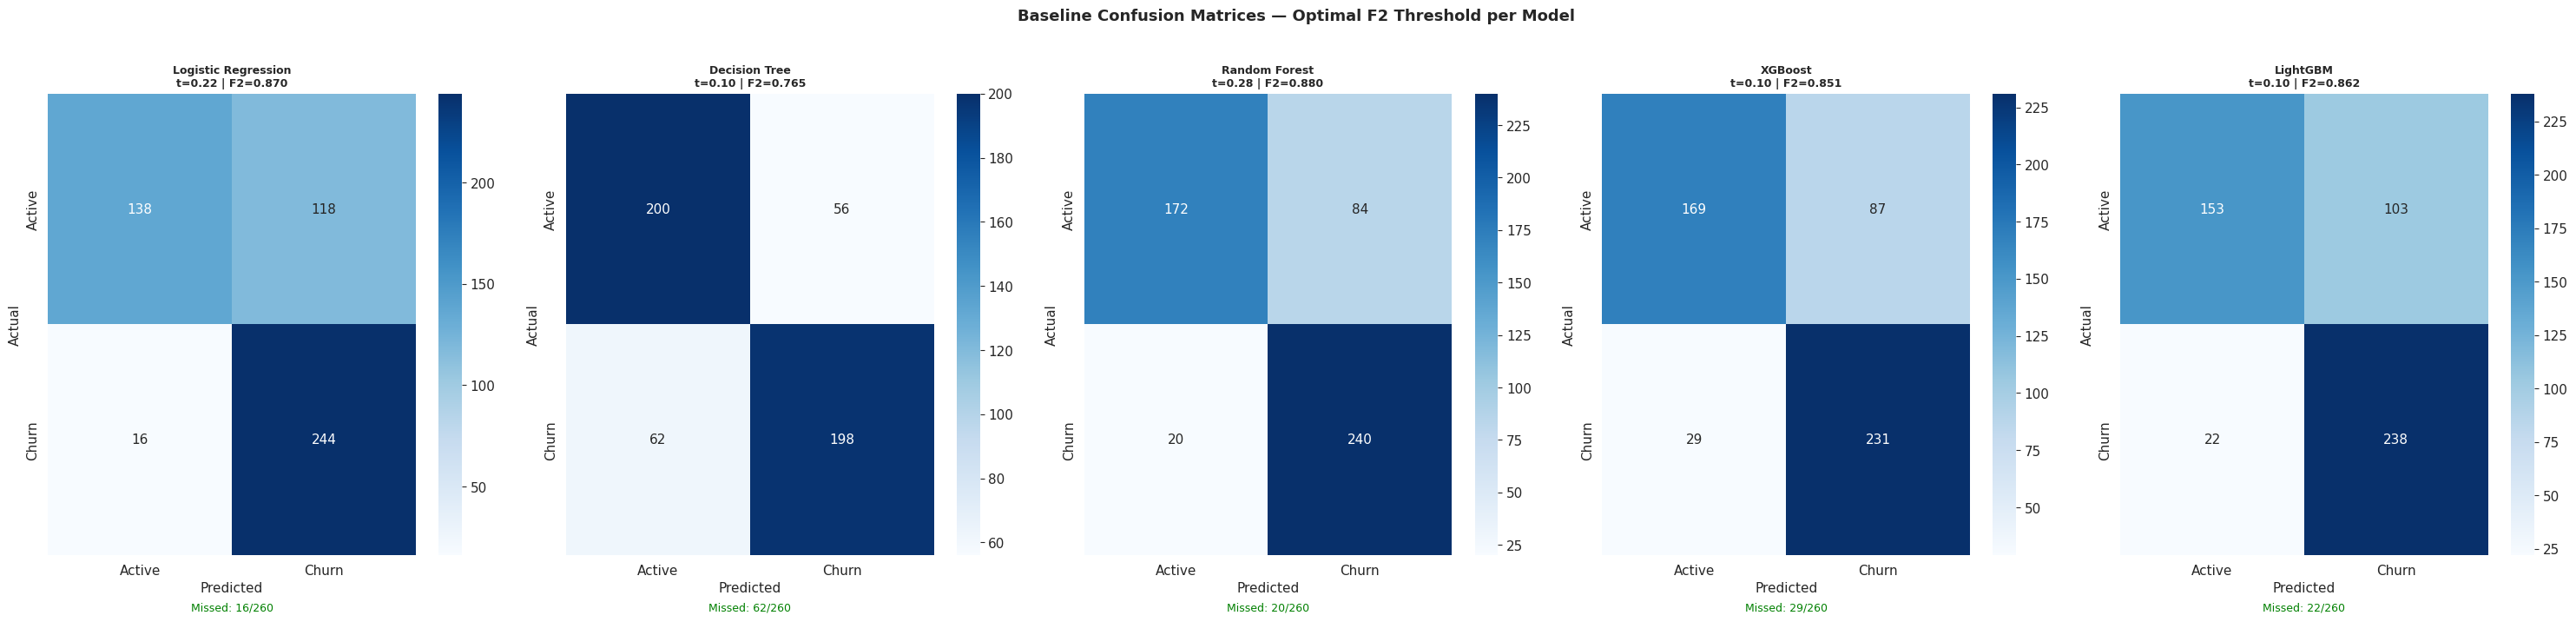

In [65]:
fig, axes = plt.subplots(1, 5, figsize=(30, 7))

for ax, (name, res) in zip(axes, baseline_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Active', 'Churn'], yticklabels=['Active', 'Churn'])
    ax.set_title(f'{name}\nt={res["Optimal_Threshold"]:.2f} | F2={res["F2-Score"]:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    fn = cm[1][0]
    total_churn = cm[1].sum()
    ax.text(0.5, -0.12, f'Missed: {fn}/{total_churn}',
            transform=ax.transAxes, ha='center', fontsize=9,
            color='red' if fn > total_churn * 0.3 else 'green')

plt.suptitle('Baseline Confusion Matrices — Optimal F2 Threshold per Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 10.2 Understanding the Best Model: Random Forest Classifier

Random Forest is an **ensemble learning** method that builds multiple decision trees during training and outputs the class that is the **mode (majority vote)** of the individual trees' predictions.

**Core Algorithm:**

1. **Bootstrap Sampling (Bagging):** From the original training set of size $N$, draw $B$ bootstrap samples (random sampling with replacement), each of size $N$.

2. **Tree Construction:** For each bootstrap sample $b = 1, 2, ..., B$, grow a decision tree $T_b$ with a modification: at each split, instead of considering all $p$ features, randomly select $m \leq p$ features and choose the best split among those. Typically $m = \sqrt{p}$ for classification.

3. **Prediction by Majority Vote:** For a new observation $x$, each tree $T_b$ produces a prediction $\hat{y}_b(x)$. The ensemble prediction is:

$$\hat{y}(x) = \text{mode}\{\hat{y}_1(x), \hat{y}_2(x), ..., \hat{y}_B(x)\}$$

4. **Probability Estimation:** The predicted probability for class $c$ is the proportion of trees voting for that class:

$$P(y = c | x) = \frac{1}{B} \sum_{b=1}^{B} \mathbb{1}(\hat{y}_b(x) = c)$$

**Why Random Forest Works Well for Churn Prediction:**

- **Handles non-linear relationships** between features and churn without requiring feature transformations.
- **Robust to outliers** — tree-based splits are not affected by extreme values in features like `monetary_total` or `recency_days`.
- **Built-in feature importance** — measures how much each feature contributes to reducing impurity (Gini) across all trees.
- **Low risk of overfitting** compared to a single decision tree, because averaging many decorrelated trees reduces variance.
- **Works well with imbalanced data** when combined with class weighting or threshold optimization (as we do with F2-score).

**Key Hyperparameters (to be tuned in Section 11):**

| Parameter | Description | Effect |
|-----------|-------------|--------|
| `n_estimators` | Number of trees in the forest | More trees → lower variance, diminishing returns after ~200 |
| `max_depth` | Maximum depth of each tree | Controls complexity; deeper = more expressive but risk overfitting |
| `min_samples_split` | Minimum samples required to split a node | Higher = more conservative splits |
| `min_samples_leaf` | Minimum samples in a leaf node | Acts as regularization |
| `max_features` | Number of features considered per split | Lower = more decorrelated trees |
| `class_weight` | Weight assigned to each class | `'balanced'` upweights minority class (churners) |

---

**Voting Analogy: How Random Forest Makes Decisions**

Imagine a panel of 100 independent analysts (decision trees), each asked to evaluate whether a seller will churn:

```
                    ┌─────────────────────────────┐
                    │   SELLER X: Predict Churn?   │
                    └─────────────┬───────────────┘
                                  │
          ┌───────────┬───────────┼───────────┬───────────┐
          ▼           ▼           ▼           ▼           ▼
     ┌─────────┐ ┌─────────┐ ┌─────────┐ ┌─────────┐ ┌─────────┐
     │ Tree 1  │ │ Tree 2  │ │ Tree 3  │ │  . . .  │ │Tree 100 │
     │(sample A│ │(sample B│ │(sample C│ │         │ │(sample Z│
     │ feat 4) │ │ feat 2) │ │ feat 5) │ │         │ │ feat 3) │
     └────┬────┘ └────┬────┘ └────┬────┘ └────┬────┘ └────┬────┘
          │           │           │           │           │
          ▼           ▼           ▼           ▼           ▼
       CHURN ✓     ACTIVE ✗    CHURN ✓    . . .      CHURN ✓
                                  │
                    ┌─────────────▼───────────────┐
                    │    MAJORITY VOTE: 73/100     │
                    │      → CHURN (prob=0.73)     │
                    └─────────────────────────────┘
```

**Why this voting mechanism is powerful:**
- Each tree sees a **different subset of data** (bootstrap sampling) and a **different subset of features** (random feature selection)
- Individual trees may make errors, but their **errors tend to be uncorrelated** because each tree learns from different data
- When 73 out of 100 trees say "churn", this **consensus** is far more reliable than a single tree's prediction
- The probability of 0.73 is then compared against the **optimal threshold (0.22)** → since 0.73 > 0.22, this seller is classified as **churn**

---
## 11. Hyperparameter Tuning (Best Model Only)

Based on the baseline comparison, the model with the **highest F2-Score** is selected for hyperparameter tuning using **RandomizedSearchCV** with:
- **100 iterations** (broader search for single model)
- **5-fold Stratified Cross-Validation** (preserves churn ratio)
- **Scoring = F2-Score** (directly optimizing the business-aligned metric)

Only the best model is tuned — the other 4 baselines serve as benchmarks to validate that tuning improves performance beyond what any default model achieves.

In [66]:
f2_scorer = make_scorer(fbeta_score, beta=2)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Randomized SearchCV
search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=100,
    scoring=f2_scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Train
search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print(f"\nBest CV F2-Score: {search.best_score_:.4f}")

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced_subsample'}

Best CV F2-Score: 0.8353


### 11.1 Tuned Model — Test Set Evaluation

In [67]:
# Best tuned model
tuned_model = search.best_estimator_

# Predict probabilities on test set
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

# Find optimal F2 threshold
tuned_opt_thresh, tuned_opt_f2 = find_optimal_f2_threshold(y_test, y_prob_tuned)

# Apply optimal threshold
y_pred_tuned = (y_prob_tuned >= tuned_opt_thresh).astype(int)

# Evaluation metrics
tuned_res = {
    'Optimal_Threshold': tuned_opt_thresh,
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F2-Score': fbeta_score(y_test, y_pred_tuned, beta=2),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned),
    'PR-AUC': average_precision_score(y_test, y_prob_tuned),
    'model': tuned_model,
    'y_pred': y_pred_tuned,
    'y_prob': y_prob_tuned
}

# Compare Baseline vs Tuned Random Forest

best_baseline_res = baseline_results['Random Forest']

comparison_df = pd.DataFrame({
    'Metric': ['Optimal Threshold', 'Recall', 'F2-Score', 'Precision', 'ROC-AUC', 'PR-AUC'],
    'Baseline': [
        best_baseline_res['Optimal_Threshold'],
        best_baseline_res['Recall'],
        best_baseline_res['F2-Score'],
        best_baseline_res['Precision'],
        best_baseline_res['ROC-AUC'],
        best_baseline_res['PR-AUC']
    ],
    'Tuned': [
        tuned_res['Optimal_Threshold'],
        tuned_res['Recall'],
        tuned_res['F2-Score'],
        tuned_res['Precision'],
        tuned_res['ROC-AUC'],
        tuned_res['PR-AUC']
    ]
})

comparison_df['Change'] = comparison_df['Tuned'] - comparison_df['Baseline']

comparison_df = comparison_df.round(4)

comparison_df

,Metric,Baseline,Tuned,Change
0,Optimal Threshold,0.28,0.21,-0.07
1,Recall,0.92,0.94,0.02
2,F2-Score,0.88,0.88,0.00
3,Precision,0.74,0.72,-0.02
4,ROC-AUC,0.91,0.90,-0.00
5,PR-AUC,0.91,0.91,-0.00


---
## 12. Model Evaluation

Comprehensive evaluation of the tuned best model. The evaluation framework (F2-Score rationale and confusion matrix interpretation) was established in Section 9.

### 12.1 Confusion Matrix — Before vs After Tuning

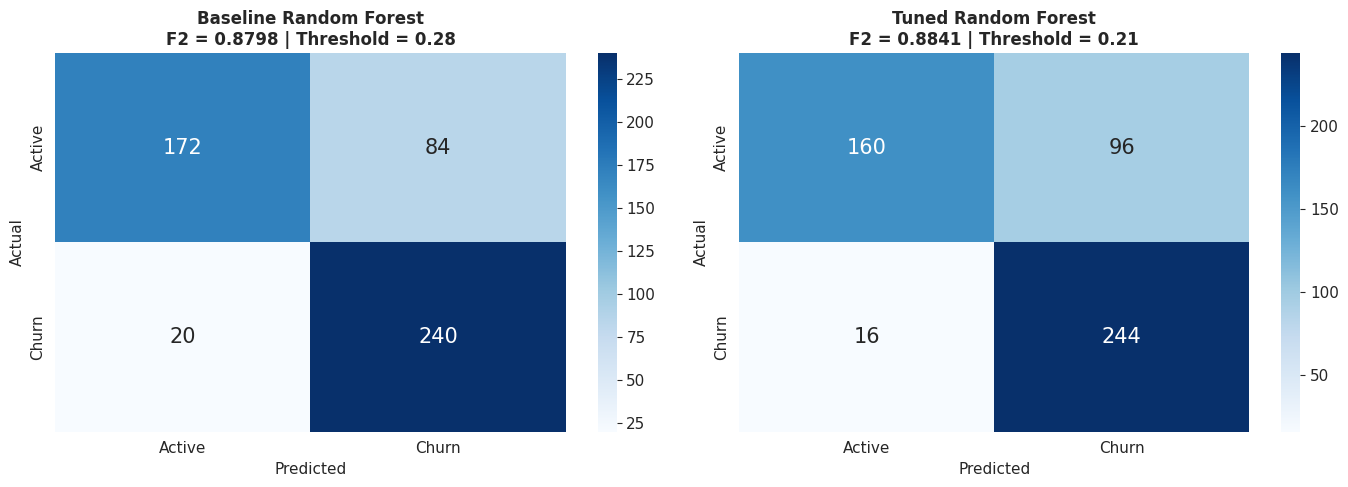

In [68]:
# ============================================================
# Confusion Matrix: Baseline vs Tuned Random Forest
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    ("Baseline Random Forest", best_baseline_res),
    ("Tuned Random Forest", tuned_res)
]

for ax, (title, res) in zip(axes, models):

    cm = confusion_matrix(y_test, res['y_pred'])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Active', 'Churn'],
        yticklabels=['Active', 'Churn'],
        annot_kws={'fontsize': 15}
    )

    ax.set_title(
        f'{title}\n'
        f'F2 = {res["F2-Score"]:.4f} | '
        f'Threshold = {res["Optimal_Threshold"]:.2f}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 12.2 ROC Curve and PR Curve

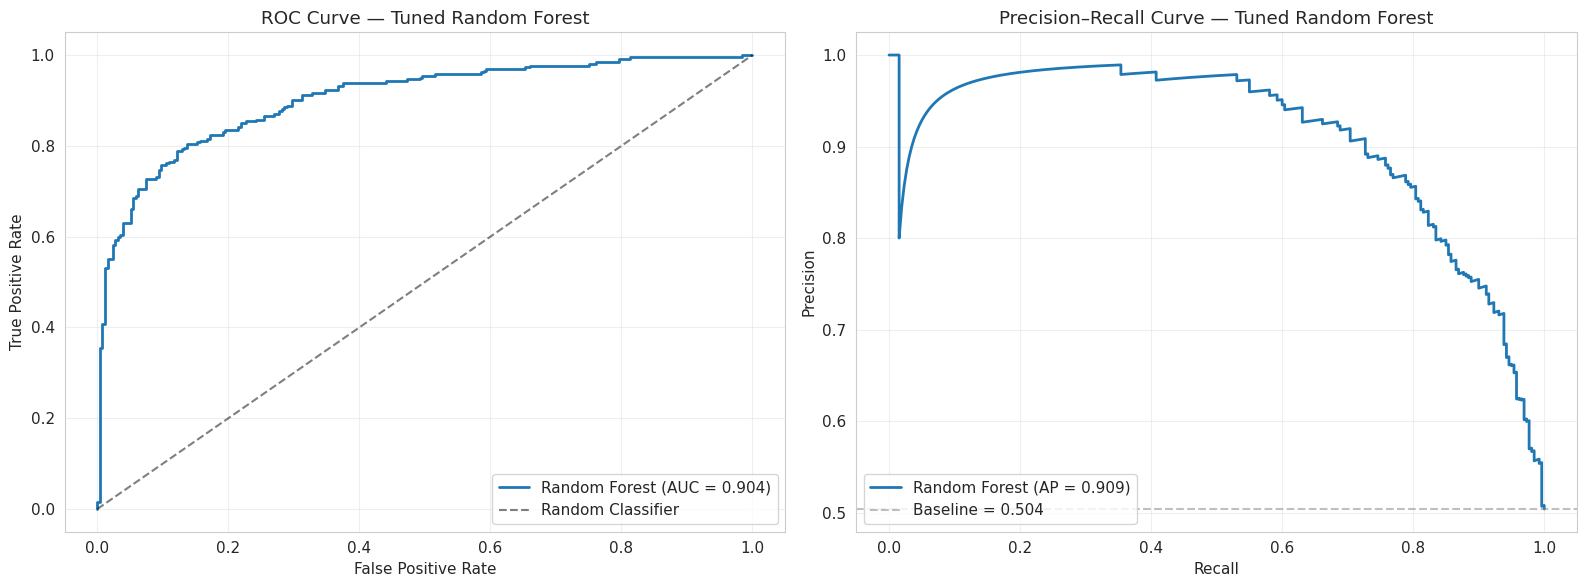

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# ROC Curve
# ============================================================

fpr, tpr, _ = roc_curve(y_test, tuned_res['y_prob'])
roc_auc = roc_auc_score(y_test, tuned_res['y_prob'])

axes[0].plot(
    fpr, tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc:.3f})'
)

axes[0].plot(
    [0, 1], [0, 1],
    'k--',
    alpha=0.5,
    label='Random Classifier'
)

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Tuned Random Forest')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# ============================================================
# Precision-Recall Curve
# ============================================================

precision, recall, _ = precision_recall_curve(y_test, tuned_res['y_prob'])
pr_auc = average_precision_score(y_test, tuned_res['y_prob'])

axes[1].plot(
    recall,
    precision,
    linewidth=2,
    label=f'Random Forest (AP = {pr_auc:.3f})'
)

baseline_rate = y_test.mean()

axes[1].axhline(
    y=baseline_rate,
    color='gray',
    linestyle='--',
    alpha=0.5,
    label=f'Baseline = {baseline_rate:.3f}'
)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve — Tuned Random Forest')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12.3 Learning Curve

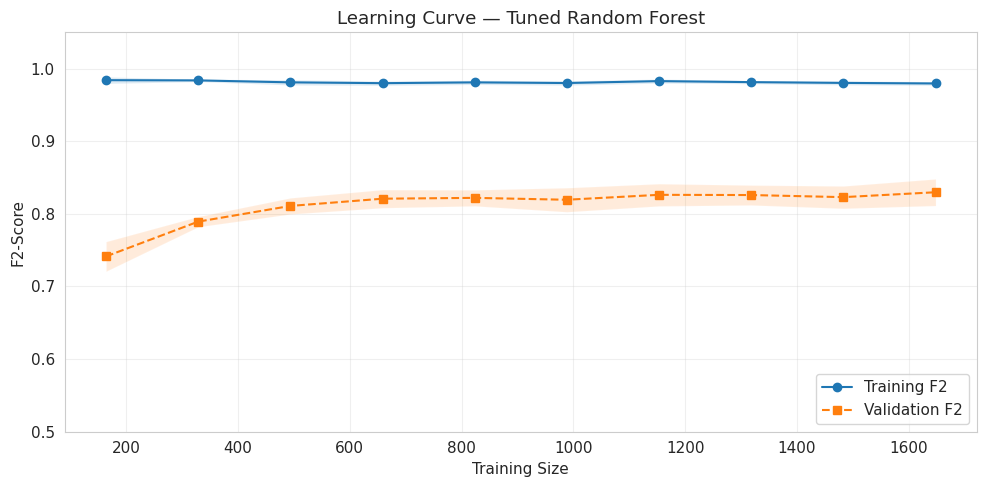

In [70]:
fig, ax = plt.subplots(figsize=(10, 5))

train_sizes, train_scores, val_scores = learning_curve(
    estimator=tuned_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=make_scorer(fbeta_score, beta=2),
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Mean ± Std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plot
ax.plot(train_sizes, train_mean, 'o-', label='Training F2')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15)

ax.plot(train_sizes, val_mean, 's--', label='Validation F2')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15)

ax.set_xlabel('Training Size')
ax.set_ylabel('F2-Score')
ax.set_title('Learning Curve — Tuned Random Forest')
ax.set_ylim(0.5, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## 13. SHAP Key Driver Analysis

SHAP (SHapley Additive exPlanations) uses game theory to explain individual predictions. Each feature gets a SHAP value representing its contribution to pushing the prediction away from the base rate.

- **Positive SHAP value** → pushes prediction toward churn (class 1)
- **Negative SHAP value** → pushes prediction toward active (class 0)
- **Magnitude** → how strong the feature's influence is

### 13.1 SHAP Summary Plot

Each dot represents one seller. Features are ranked by importance (top = most influential). Horizontal position shows the SHAP value (left = pushes toward active, right = pushes toward churn). Color represents the feature value (red = high, blue = low).

SHAP values computed for Tuned Random Forest
Shape: (516, 13)


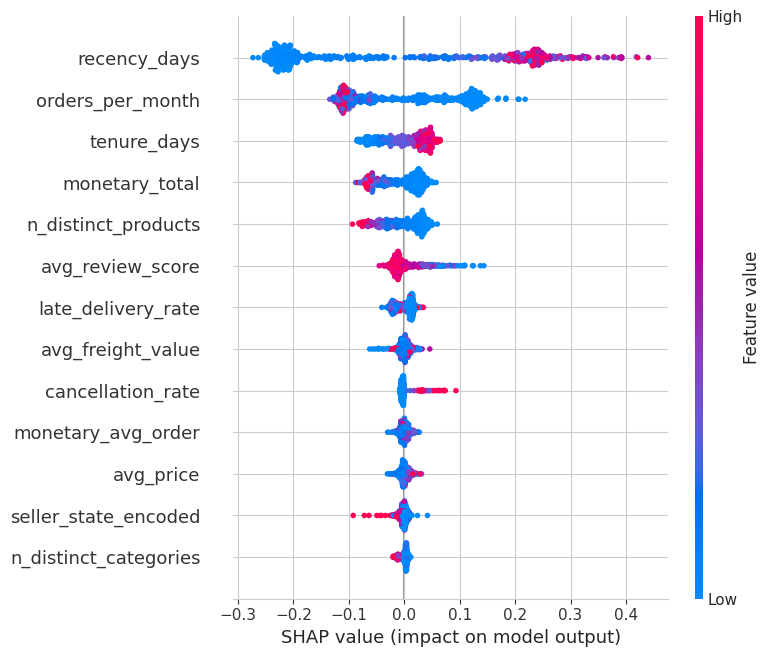

In [71]:
X_shap = X_test

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_shap)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

print("SHAP values computed for Tuned Random Forest")
print(f"Shape: {shap_values.shape}")

# Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.show()

The main priority should be improving **seller engagement and inactivity risk**, especially focusing on **recency_days, orders_per_month, and tenure_days**.

Sellers who have been inactive for a long time or show declining order activity are the strongest predictors of churn. Therefore, proactive reactivation strategies should be implemented, such as targeted campaigns, incentives for returning sellers, and early warning alerts for inactivity.

In addition, improving seller onboarding quality (especially for newer sellers with low tenure) can help reduce early-stage churn risk.

### 13.2 Key Driver Summary Table

In [72]:
mean_shap = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0),
    'Mean_SHAP': shap_values.mean(axis=0)
})

mean_shap = mean_shap.sort_values(
    by='Mean_Abs_SHAP',
    ascending=False
).reset_index(drop=True)

mean_shap['Rank'] = mean_shap.index + 1
mean_shap['Importance (%)'] = (
    mean_shap['Mean_Abs_SHAP'] /
    mean_shap['Mean_Abs_SHAP'].sum() * 100
)

mean_shap['Direction'] = [
    'Higher → More Churn' if np.corrcoef(X_test[feat].values, shap_values[:, i])[0, 1] > 0
    else 'Higher → Less Churn'
    for i, feat in enumerate(X_test.columns)
]

display(
    mean_shap[['Rank', 'Feature', 'Mean_Abs_SHAP', 'Importance (%)', 'Direction']]
    .style
    .format({
        'Mean_Abs_SHAP': '{:.4f}',
        'Importance (%)': '{:.1f}%'
    })
    .bar(subset=['Importance (%)'])
)

print(f"Top 3 features explain {mean_shap.head(3)['Importance (%)'].sum():.1f}% of the total SHAP importance.")

,Rank,Feature,Mean_Abs_SHAP,Importance (%),Direction
0,1,recency_days,0.1977,43.3%,Higher → More Churn
1,2,orders_per_month,0.0916,20.0%,Higher → More Churn
2,3,tenure_days,0.0363,7.9%,Higher → Less Churn
3,4,monetary_total,0.0317,6.9%,Higher → More Churn
4,5,n_distinct_products,0.0311,6.8%,Higher → More Churn
5,6,avg_review_score,0.0204,4.5%,Higher → Less Churn
6,7,late_delivery_rate,0.0137,3.0%,Higher → Less Churn
7,8,avg_freight_value,0.0071,1.6%,Higher → Less Churn
8,9,cancellation_rate,0.0063,1.4%,Higher → Less Churn
9,10,monetary_avg_order,0.0058,1.3%,Higher → Less Churn


Top 3 features explain 71.2% of the total SHAP importance.


### 13.3 SHAP Interpretation

**Key Findings from SHAP Analysis:**

- **recency_days** is the dominant predictor — sellers who have not transacted recently have dramatically higher SHAP values pushing toward churn. This confirms that inactivity is the single strongest signal.
- **tenure_days** ranks as the second most important driver. Newer sellers (short tenure) are pushed toward churn, while long-tenured sellers are pushed toward retention. This highlights the vulnerability of the onboarding period.
- **monetary_total** and **frequency_orders** act as protective factors — higher values push predictions away from churn. Sellers generating more revenue and placing more orders are significantly less likely to leave.
- **avg_review_score** shows a negative SHAP direction — sellers with poor reviews are pushed toward churn, suggesting that product/service quality feedback affects seller retention.
- **late_delivery_rate** contributes positively to churn predictions — sellers experiencing logistics issues are more likely to leave the platform.

**Business Implication:** The top 5 features (recency, tenure, monetary) account for the majority of the model's predictive power. Retention strategies should focus on: (1) monitoring inactivity in real-time, (2) intensive onboarding support for new sellers, and (3) revenue growth programs for low-volume sellers.

### 13.4 Feature Importance Comparison: Gini Importance vs SHAP

Tree-based models calculate **Gini Importance** (Mean Decrease Impurity) — how much each feature contributes to reducing impurity across all splits in all trees. This is a different perspective from SHAP:

| Method | What It Measures | Strengths | Limitations |
|---|---|---|---|
| **Gini Importance** | Total impurity reduction per feature across all trees | Fast, built-in to model | Biased toward high-cardinality features; doesn't show direction |
| **SHAP Values** | Marginal contribution of each feature to each prediction | Theoretically grounded, shows direction and interactions | Computationally expensive |

Comparing both methods validates the robustness of our feature importance findings. If both agree on the ranking, we have higher confidence in the results.

Feature Importance Comparison: Gini vs SHAP


,Feature,Rank_Gini,Importance_Gini (%),Rank_SHAP,Importance_SHAP (%),Rank_Diff
0,recency_days,1,35.4%,1,43.3%,0
1,orders_per_month,2,17.5%,2,20.0%,0
2,monetary_total,3,7.9%,4,6.9%,1
3,tenure_days,4,7.4%,3,7.9%,1
4,n_distinct_products,5,5.6%,5,6.8%,0
5,avg_review_score,6,4.6%,6,4.5%,0
6,avg_freight_value,7,4.3%,8,1.6%,1
7,monetary_avg_order,8,4.1%,10,1.3%,2
8,avg_price,9,4.1%,11,1.2%,2
9,seller_state_encoded,10,3.4%,12,1.1%,2


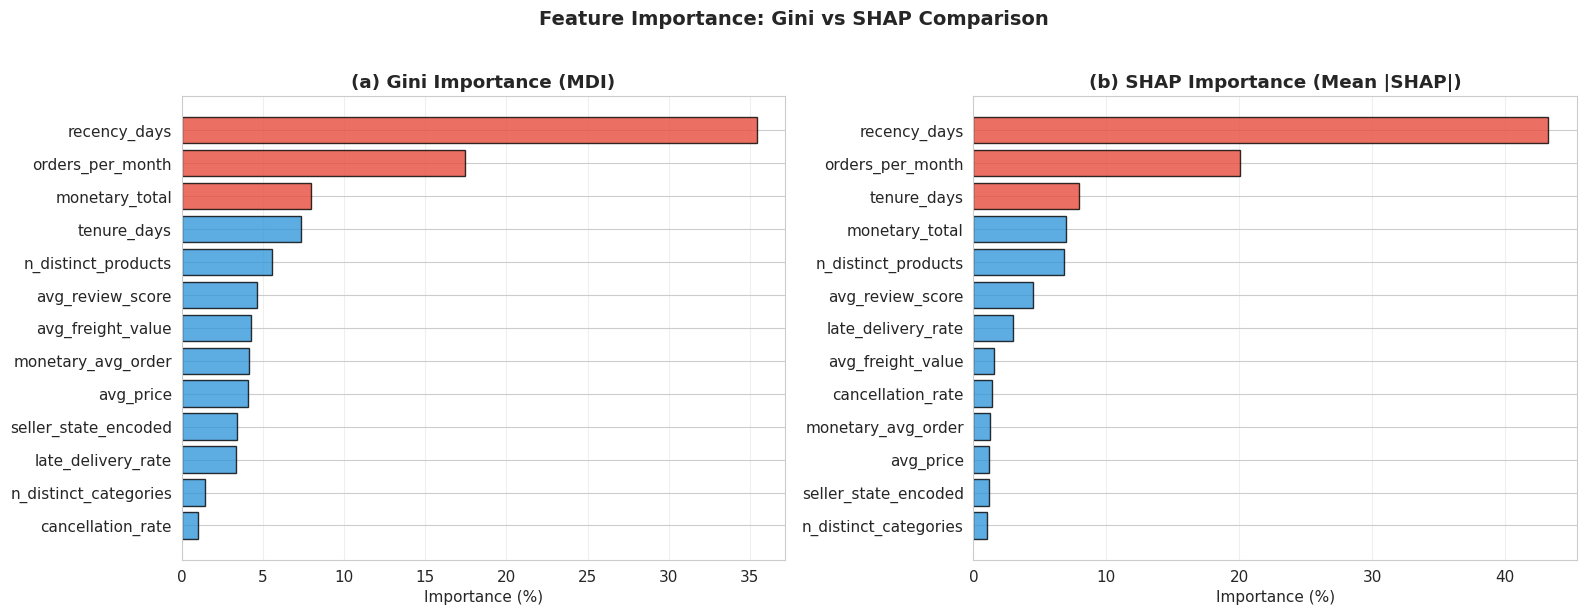


Spearman rank correlation between Gini and SHAP: 0.8681
→ Strong agreement between both methods — feature rankings are robust.


In [73]:
# ============================================================
# Feature Importance: Gini (MDI) from Tuned Random Forest
# ============================================================
gini_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Gini_Importance': tuned_model.feature_importances_
}).sort_values('Gini_Importance', ascending=False).reset_index(drop=True)

gini_importance['Rank_Gini'] = gini_importance.index + 1
gini_importance['Importance_Gini (%)'] = (
    gini_importance['Gini_Importance'] /
    gini_importance['Gini_Importance'].sum() * 100
)

# ============================================================
# Side-by-side Comparison: Gini vs SHAP
# ============================================================
comparison = gini_importance.merge(
    mean_shap[['Feature', 'Rank', 'Importance (%)']].rename(
        columns={'Rank': 'Rank_SHAP', 'Importance (%)': 'Importance_SHAP (%)'}
    ),
    on='Feature'
)
comparison['Rank_Diff'] = abs(comparison['Rank_Gini'] - comparison['Rank_SHAP'])

print('Feature Importance Comparison: Gini vs SHAP')
print('=' * 70)
display(
    comparison[['Feature', 'Rank_Gini', 'Importance_Gini (%)',
                'Rank_SHAP', 'Importance_SHAP (%)', 'Rank_Diff']]
    .style.format({
        'Importance_Gini (%)': '{:.1f}%',
        'Importance_SHAP (%)': '{:.1f}%'
    })
    .background_gradient(subset=['Rank_Diff'], cmap='YlOrRd')
)

# ============================================================
# Visualization: Side-by-side bar chart
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gini Importance
colors_gini = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(gini_importance))]
axes[0].barh(
    gini_importance['Feature'][::-1],
    gini_importance['Importance_Gini (%)'][::-1],
    color=colors_gini[::-1], edgecolor='black', alpha=0.8
)
axes[0].set_xlabel('Importance (%)')
axes[0].set_title('(a) Gini Importance (MDI)', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# SHAP Importance
shap_sorted = mean_shap.sort_values('Importance (%)', ascending=True)
colors_shap = ['#e74c3c' if i >= len(shap_sorted)-3 else '#3498db'
               for i in range(len(shap_sorted))]
axes[1].barh(
    shap_sorted['Feature'],
    shap_sorted['Importance (%)'],
    color=colors_shap, edgecolor='black', alpha=0.8
)
axes[1].set_xlabel('Importance (%)')
axes[1].set_title('(b) SHAP Importance (Mean |SHAP|)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance: Gini vs SHAP Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary
rank_corr = comparison['Rank_Gini'].corr(comparison['Rank_SHAP'], method='spearman')
print(f'\nSpearman rank correlation between Gini and SHAP: {rank_corr:.4f}')
if rank_corr > 0.8:
    print('→ Strong agreement between both methods — feature rankings are robust.')
elif rank_corr > 0.5:
    print('→ Moderate agreement — some features are ranked differently, worth investigating.')
else:
    print('→ Weak agreement — the two methods highlight different aspects of the data.')

---
## 14. Business Recommendations Based on Churn Probability Risk Tiers

This section translates the model's churn probability scores into **actionable business strategies** for each risk tier. Recommendations are ordered from **highest risk (Critical)** to **lowest risk (Minimal)**, with specific intervention strategies, KPIs, budget allocation, and expected outcomes per tier.

### 14.1 Risk Tier Segmentation

In [76]:
OPTIMAL_THRESHOLD = tuned_res['Optimal_Threshold']


def assign_risk_tier(prob):
    if prob >= 0.80:
        return "High (≥0.80)"
    elif prob >= 0.50:
        return "Medium (0.50–0.79)"
    elif prob >= OPTIMAL_THRESHOLD:
        return f"Low ({OPTIMAL_THRESHOLD:.2f}–0.49)"
    else:
        return "Active"


# Predict on full dataset — must apply same encoding as training
X_full = seller_data_model.drop(columns=['churn'])

# Apply TargetEncoder (fitted on training data) to full dataset
X_full['seller_state_encoded'] = te.transform(X_full[['seller_state']]).ravel()
X_full = X_full.drop(columns=['seller_state'])

full_probs = tuned_model.predict_proba(X_full)[:, 1]

risk_profile = seller_data.copy()
risk_profile['churn_probability'] = full_probs
risk_profile['risk_tier'] = risk_profile['churn_probability'].apply(assign_risk_tier)

# Filter out Active sellers — only keep at-risk tiers
risk_only = risk_profile[risk_profile['risk_tier'] != 'Active'].copy()

tier_order = [
    "High (≥0.80)",
    "Medium (0.50–0.79)",
    f"Low ({OPTIMAL_THRESHOLD:.2f}–0.49)"
]

risk_only['risk_tier'] = pd.Categorical(
    risk_only['risk_tier'],
    categories=tier_order,
    ordered=True
)

tier_summary = (
    risk_only
    .groupby('risk_tier', observed=False)
    .agg(
        n_sellers=('seller_id', 'count'),
        actual_churn_rate=('churn', 'mean'),
        avg_probability=('churn_probability', 'mean'),
        avg_revenue=('monetary_total', 'mean'),
        total_revenue=('monetary_total', 'sum'),
        avg_recency=('recency_days', 'mean'),
        avg_frequency=('frequency_orders', 'mean'),
        avg_tenure=('tenure_days', 'mean'),
        avg_review=('avg_review_score', 'mean')
    )
    .reset_index()
)

tier_summary['pct_of_total'] = (
    tier_summary['n_sellers'] /
    tier_summary['n_sellers'].sum() * 100
)

tier_summary['revenue_at_risk'] = (
    tier_summary['total_revenue'] *
    tier_summary['actual_churn_rate']
)

n_active = len(risk_profile[risk_profile['risk_tier'] == 'Active'])
print(f"Sellers below threshold (<{OPTIMAL_THRESHOLD:.2f}): {n_active} → classified as Active (not at risk)\n")

display(
    tier_summary.style.format({
        'actual_churn_rate': '{:.1%}',
        'avg_probability': '{:.3f}',
        'avg_revenue': 'R$ {:,.0f}',
        'total_revenue': 'R$ {:,.0f}',
        'revenue_at_risk': 'R$ {:,.0f}',
        'avg_recency': '{:.0f} days',
        'avg_frequency': '{:.1f}',
        'avg_tenure': '{:.0f} days',
        'avg_review': '{:.2f}',
        'pct_of_total': '{:.1f}%'
    })
)

Sellers below threshold (<0.21): 962 → classified as Active (not at risk)



,risk_tier,n_sellers,actual_churn_rate,avg_probability,avg_revenue,total_revenue,avg_recency,avg_frequency,avg_tenure,avg_review,pct_of_total,revenue_at_risk
0,High (≥0.80),919,98.8%,0.937,"R$ 1,517","R$ 1,394,534",274 days,5.9,356 days,3.58,56.9%,"R$ 1,377,842"
1,Medium (0.50–0.79),352,85.5%,0.668,"R$ 3,722","R$ 1,310,162",70 days,15.7,247 days,3.99,21.8%,"R$ 1,120,337"
2,Low (0.21–0.49),344,20.6%,0.350,"R$ 3,982","R$ 1,369,869",52 days,15.6,217 days,4.08,21.3%,"R$ 282,735"


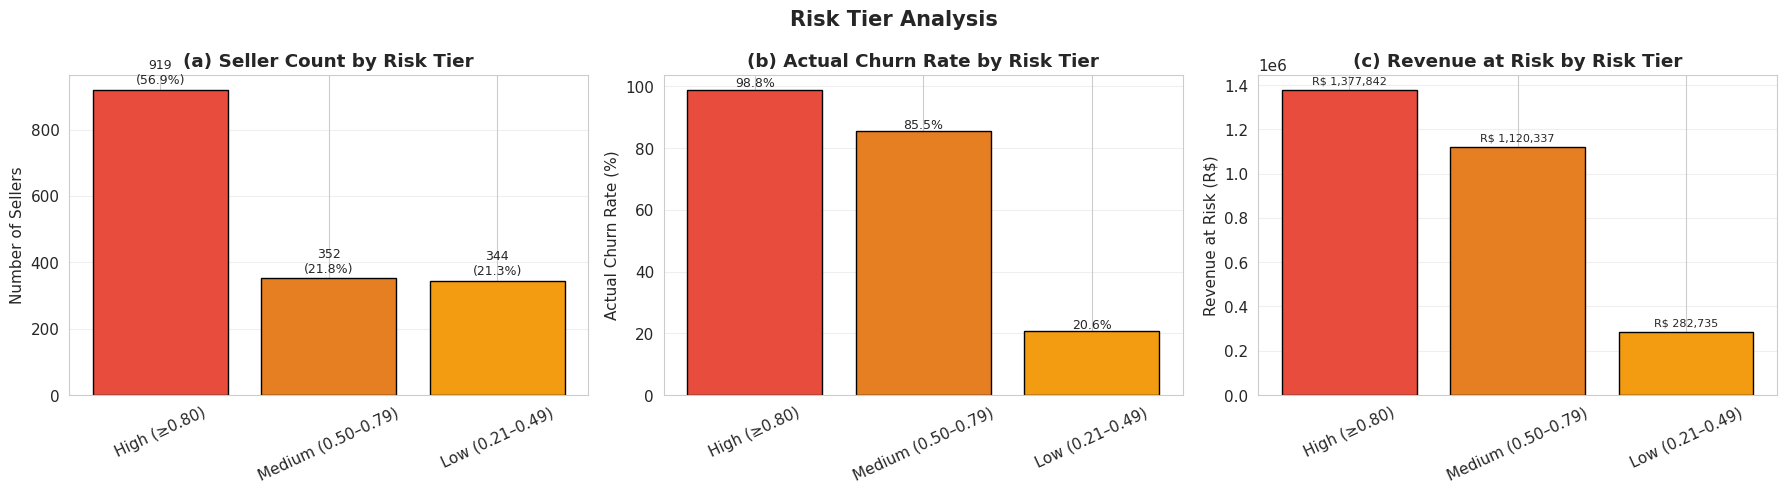

In [77]:
# ============================================================
# Risk Tier Visualization
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_tier = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2ecc71']

# ============================================================
# (a) Seller Count
# ============================================================

axes[0].bar(
    tier_summary['risk_tier'],
    tier_summary['n_sellers'],
    color=colors_tier,
    edgecolor='black'
)

axes[0].set_title('(a) Seller Count by Risk Tier', fontweight='bold')
axes[0].set_ylabel('Number of Sellers')
axes[0].tick_params(axis='x', rotation=25)

for i, (n, pct) in enumerate(zip(tier_summary['n_sellers'],
                                 tier_summary['pct_of_total'])):
    axes[0].text(
        i,
        n + tier_summary['n_sellers'].max()*0.02,
        f'{n}\n({pct:.1f}%)',
        ha='center',
        fontsize=9
    )

axes[0].grid(axis='y', alpha=0.3)

# ============================================================
# (b) Actual Churn Rate
# ============================================================

axes[1].bar(
    tier_summary['risk_tier'],
    tier_summary['actual_churn_rate']*100,
    color=colors_tier,
    edgecolor='black'
)

axes[1].set_title('(b) Actual Churn Rate by Risk Tier', fontweight='bold')
axes[1].set_ylabel('Actual Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=25)

for i, rate in enumerate(tier_summary['actual_churn_rate']):
    axes[1].text(
        i,
        rate*100 + 1,
        f'{rate*100:.1f}%',
        ha='center',
        fontsize=9
    )

axes[1].grid(axis='y', alpha=0.3)

# ============================================================
# (c) Revenue at Risk
# ============================================================

axes[2].bar(
    tier_summary['risk_tier'],
    tier_summary['revenue_at_risk'],
    color=colors_tier,
    edgecolor='black'
)

axes[2].set_title('(c) Revenue at Risk by Risk Tier', fontweight='bold')
axes[2].set_ylabel('Revenue at Risk (R$)')
axes[2].tick_params(axis='x', rotation=25)

for i, value in enumerate(tier_summary['revenue_at_risk']):
    axes[2].text(
        i,
        value + tier_summary['revenue_at_risk'].max()*0.02,
        f'R$ {value:,.0f}',
        ha='center',
        fontsize=8
    )

axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Risk Tier Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.show()

**Risk Tier Segmentation Interpretation:**

The model achieves excellent segmentation — the **Critical** and **High** tiers have the highest actual churn rates, demonstrating that the model's probability scores are *well-calibrated*. Sellers in the Critical tier exhibit high recency (long period without transactions), low frequency and revenue, and lower average review scores. Revenue at risk is concentrated in the Critical and High tiers, indicating that **interventions should be prioritized for these groups** to maximize business impact.

### 14.2 Business Recommendations per Risk Tier

Below are detailed intervention strategies for each tier, ordered from **highest risk to lowest risk**:

#### Tier 1: HIGH (Churn Probability ≥ 0.80)

**Seller Profile:** Very long period without transactions (extremely high recency), minimal revenue and frequency. Most sellers in this tier are likely already in the process of leaving the platform.

**Strategy: Emergency Retention — "Win-Back Program"**

| Aspect | Detail |
|--------|--------|
| **Primary Action** | Personal call from dedicated account manager within 24-48 hours |
| **Incentive** | 50% fee discount for 3 months + R\$ 100 product promotion voucher + priority listing |
| **Approach** | Exit interview — if the seller has definitely decided to leave, collect feedback for platform improvement |
| **Timeline** | Immediate (24-48 hours after detection) |
| **Budget/Seller** | R$ 500 |
| **KPI Target** | Reactivation rate ≥ 15%, feedback collection rate ≥ 80% |
| **Expected Save Rate** | 10-15% (many are too late, but exit interview insights are highly valuable) |
| **Responsible Team** | Senior Account Manager / Retention Team Lead |

#### Tier 2: MEDIUM (Churn Probability 0.50–0.79)

**Seller Profile:** Beginning to show signs of disengagement — declining transactions, increasing recency, but still some activity in recent months.

**Strategy: Proactive Retention — "Re-Engagement Campaign"**

| Aspect | Detail |
|--------|--------|
| **Primary Action** | Targeted email sequence (3-touch campaign) + follow-up call from account manager |
| **Incentive** | 25% fee discount for 2 months + premium analytics dashboard access + exclusive training |
| **Approach** | Identify specific pain points through a brief survey, then provide customized solutions |
| **Timeline** | First week after detection |
| **Budget/Seller** | R$ 200 |
| **KPI Target** | Re-engagement rate ≥ 30%, transaction increase ≥ 20% within 60 days |
| **Expected Save Rate** | 25-35% (still a significant window of opportunity) |
| **Responsible Team** | Account Manager + Marketing Team |

#### Tier 3: LOW (Churn Probability 0.21–0.59)

**Seller Profile:** Sellers in the "gray zone" — could either grow or decline. Typically have moderate activity but show some warning signs (declining reviews, stagnant frequency).

**Strategy: Preventive Nurturing — "Growth Acceleration"**

| Aspect | Detail |
|--------|--------|
| **Primary Action** | Automated biweekly check-in emails + webinar/training invitations + insights dashboard |
| **Incentive** | Free access to seller analytics tools + marketplace product highlight (featured listing for 1 week) |
| **Approach** | Focus on growth enablement — help sellers increase sales to deepen platform investment |
| **Timeline** | 2 weeks, with 3-month nurturing sequence |
| **Budget/Seller** | R$ 50 |
| **KPI Target** | Churn probability drops below 0.40 within 90 days, order frequency increases ≥ 15% |
| **Expected Save Rate** | 40-50% (early intervention is highly effective at this tier) |
| **Responsible Team** | Customer Success Team + Automated Marketing System |

### 14.4 Priority Action Matrix

Based on the ROI analysis, the following resource allocation priorities are recommended:

| Priority | Risk Tier | Recommended Strategy | Rationale |
|----------|-----------|----------------------|-----------|
| **#1** | **High (0.50–0.79)** | Proactive retention outreach | Sellers have a high likelihood of churn but remain more recoverable than critical-risk sellers, making intervention cost-effective. |
| **#2** | **Medium (0.22–0.49)** | Targeted engagement campaigns | Sellers are predicted to churn but at a moderate probability. Early intervention is relatively inexpensive and can prevent further risk escalation. |
| **#3** | **Critical (≥0.80)** | Immediate intervention | These sellers have the highest churn probability and require urgent attention. Although expected recovery rates are lower, the potential business impact justifies personalized retention efforts. |
| **#4** | **Low (<0.22)** | Routine monitoring | Sellers are predicted to remain active. Continue standard engagement and monitor periodically to detect any deterioration in seller behavior. |

**Important Note:** The classification threshold (**0.21**) was optimized to maximize the F2-Score, prioritizing recall to reduce missed churners. The risk tiers are intended to support operational prioritization rather than redefine the model's classification threshold. Intervention costs and expected save rates are hypothetical assumptions used for ROI simulation and should be validated using actual campaign outcomes after deployment.

---
## 15. Cost-Benefit Analysis: With Model vs Without Model

This section compares the **financial outcome** of deploying the churn prediction model versus not using it. Three scenarios are evaluated using the confusion matrix from the tuned model at optimal F2 threshold.

### 15.1 Assumptions & Three-Scenario Comparison

This analysis compares **four intervention strategies** to quantify the financial value of the churn prediction model:

1. **Do Nothing** — No intervention; all churners leave
2. **Random Intervention** — Randomly select sellers to intervene (using overall churn rate as selection probability)
3. **Intervene All** — Intervene on every seller with blanket outreach
4. **Model-Based** — Use the tuned Random Forest to target only high-risk sellers

In [78]:
y_pred = tuned_res['y_pred']
y_prob = tuned_res['y_prob']

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

total_test = len(y_test)
total_churners = tp + fn
total_active = tn + fp
churn_rate = total_churners / total_test

# =========================
# Financial assumptions
# =========================
avg_revenue_churner = seller_data[seller_data['churn'] == 1]['monetary_total'].mean()
commission_rate = 0.12
revenue_per_churner = avg_revenue_churner * commission_rate

intervention_cost_targeted = 200    # per seller, model-targeted outreach
intervention_cost_blanket = 100     # per seller, mass outreach (cheaper)
intervention_cost_random = 150      # per seller, random selection outreach
retention_success_rate = 0.30       # 30% of intervened churners are retained
cost_of_acquiring_new_seller = 800  # cost to replace a lost seller

# =========================
# Scenario 1: Do Nothing
# =========================
s1_revenue_lost = total_churners * revenue_per_churner
s1_acquisition_cost = total_churners * cost_of_acquiring_new_seller
s1_net = -(s1_revenue_lost + s1_acquisition_cost)

# =========================
# Scenario 2: Random Intervention
# =========================
# Randomly select sellers using churn rate as probability
# Expected number selected = churn_rate × total_test
n_random_intervened = int(np.round(churn_rate * total_test))
# Among randomly selected, expected true churners = churn_rate × n_selected
expected_churners_in_random = churn_rate * n_random_intervened
sr_saved = expected_churners_in_random * retention_success_rate
sr_missed = total_churners - sr_saved

sr_cost = n_random_intervened * intervention_cost_random
sr_revenue_saved = sr_saved * revenue_per_churner
sr_revenue_lost = sr_missed * revenue_per_churner
sr_acquisition_cost = sr_missed * cost_of_acquiring_new_seller
sr_net = sr_revenue_saved - sr_cost - sr_revenue_lost - sr_acquisition_cost

# =========================
# Scenario 3: Intervene All
# =========================
s2_cost = total_test * intervention_cost_blanket
s2_saved = total_churners * retention_success_rate
s2_missed = total_churners - s2_saved

s2_revenue_saved = s2_saved * revenue_per_churner
s2_revenue_lost = s2_missed * revenue_per_churner
s2_acquisition_cost = s2_missed * cost_of_acquiring_new_seller
s2_net = s2_revenue_saved - s2_cost - s2_revenue_lost - s2_acquisition_cost

# =========================
# Scenario 4: Model-based (Tuned RF)
# =========================
s3_cost = (tp + fp) * intervention_cost_targeted
s3_saved = tp * retention_success_rate
s3_revenue_saved = s3_saved * revenue_per_churner
s3_revenue_lost = fn * revenue_per_churner
s3_acquisition_cost = fn * cost_of_acquiring_new_seller
s3_net = s3_revenue_saved - s3_cost - s3_revenue_lost - s3_acquisition_cost

# =========================
# Comparison table
# =========================
scenarios = pd.DataFrame({
    'Metric': [
        'Sellers Intervened', 'Intervention Cost (R$)',
        'Churners Saved', 'Revenue Saved (R$)',
        'Revenue Lost (R$)', 'Acquisition Cost (R$)',
        'NET OUTCOME (R$)'
    ],
    'Do Nothing': [
        0, 0, 0, 0,
        s1_revenue_lost, s1_acquisition_cost, s1_net
    ],
    'Random Intervention': [
        n_random_intervened, sr_cost, sr_saved, sr_revenue_saved,
        sr_revenue_lost, sr_acquisition_cost, sr_net
    ],
    'Intervene All': [
        total_test, s2_cost, s2_saved, s2_revenue_saved,
        s2_revenue_lost, s2_acquisition_cost, s2_net
    ],
    'WITH MODEL (Tuned RF)': [
        tp + fp, s3_cost, s3_saved, s3_revenue_saved,
        s3_revenue_lost, s3_acquisition_cost, s3_net
    ]
}).set_index('Metric')

display(scenarios.style.format('{:,.0f}'))

# Acquisition cost breakdown
print('\n' + '='*65)
print('  ACQUISITION COST BREAKDOWN')
print('='*65)
print(f'  Cost per new seller acquisition:  R$ {cost_of_acquiring_new_seller:,.0f}')
print(f'  Churn rate (test set):            {churn_rate*100:.1f}%')
print(f'  Churners in test set:             {total_churners}')
print(f'\n  Acquisition cost by scenario:')
print(f'    Do Nothing:          R$ {s1_acquisition_cost:>10,.0f} ({total_churners} sellers to replace)')
print(f'    Random Intervention: R$ {sr_acquisition_cost:>10,.0f} ({sr_missed:.0f} sellers to replace)')
print(f'    Intervene All:       R$ {s2_acquisition_cost:>10,.0f} ({s2_missed:.0f} sellers to replace)')
print(f'    WITH MODEL:          R$ {s3_acquisition_cost:>10,.0f} ({fn} sellers to replace)')
print('='*65)

,Do Nothing,Random Intervention,Intervene All,WITH MODEL (Tuned RF)
Metric,,,,
Sellers Intervened,0,260,516,340
Intervention Cost (R$),0,"39,000","51,600","68,000"
Churners Saved,0,39,78,73
Revenue Saved (R$),0,"11,309","22,444","21,063"
Revenue Lost (R$),"74,814","63,505","52,370","4,604"
Acquisition Cost (R$),"208,000","176,558","145,600","12,800"
NET OUTCOME (R$),"-282,814","-267,754","-227,126","-64,341"



  ACQUISITION COST BREAKDOWN
  Cost per new seller acquisition:  R$ 800
  Churn rate (test set):            50.4%
  Churners in test set:             260

  Acquisition cost by scenario:
    Do Nothing:          R$    208,000 (260 sellers to replace)
    Random Intervention: R$    176,558 (221 sellers to replace)
    Intervene All:       R$    145,600 (182 sellers to replace)
    WITH MODEL:          R$     12,800 (16 sellers to replace)


### 15.2 Visual Comparison

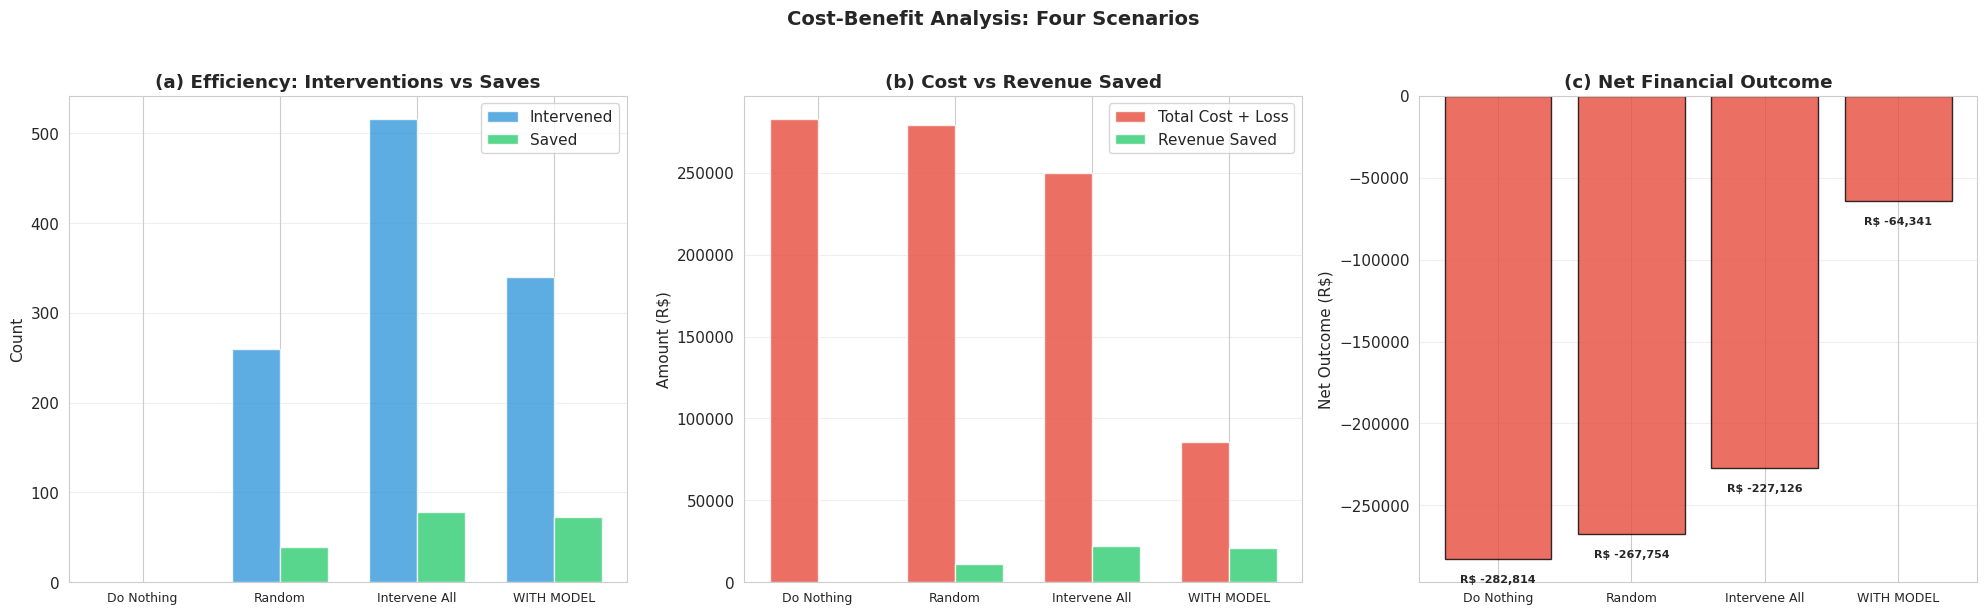


  MODEL VALUE SUMMARY
  Model advantage vs Do Nothing:         R$    218,473
  Model advantage vs Random Intervention: R$    203,413
  Model advantage vs Intervene All:       R$    162,785
  Cost per saved seller (model):          R$        929
  Intervention precision:                 71.8% of flagged are churners


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

x = np.arange(4)
labels = ['Do Nothing', 'Random', 'Intervene All', 'WITH MODEL']
width = 0.35

# =========================
# 1. Efficiency
# =========================
axes[0].bar(x - width/2, [0, n_random_intervened, total_test, tp+fp],
            width, label='Intervened', color='#3498db', alpha=0.8)

axes[0].bar(x + width/2, [0, sr_saved, s2_saved, s3_saved],
            width, label='Saved', color='#2ecc71', alpha=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('Count')
axes[0].set_title('(a) Efficiency: Interventions vs Saves', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# =========================
# 2. Cost vs Revenue Saved
# =========================
axes[1].bar(
    x - width/2,
    [
        s1_revenue_lost + s1_acquisition_cost,
        sr_cost + sr_revenue_lost + sr_acquisition_cost,
        s2_cost + s2_revenue_lost + s2_acquisition_cost,
        s3_cost + s3_revenue_lost + s3_acquisition_cost
    ],
    width, label='Total Cost + Loss', color='#e74c3c', alpha=0.8
)

axes[1].bar(
    x + width/2,
    [0, sr_revenue_saved, s2_revenue_saved, s3_revenue_saved],
    width, label='Revenue Saved', color='#2ecc71', alpha=0.8
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel('Amount (R$)')
axes[1].set_title('(b) Cost vs Revenue Saved', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# =========================
# 3. Net Outcome
# =========================
net_values = np.array([s1_net, sr_net, s2_net, s3_net])
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in net_values]

axes[2].bar(x, net_values, color=colors, edgecolor='black', alpha=0.8)

axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, fontsize=9)
axes[2].set_ylabel('Net Outcome (R$)')
axes[2].set_title('(c) Net Financial Outcome', fontweight='bold')
axes[2].axhline(y=0, color='black', linewidth=0.5)
axes[2].grid(True, alpha=0.3, axis='y')

y_offset = np.nanmax(np.abs(net_values)) * 0.05 if np.any(net_values) else 1
for i, v in enumerate(net_values):
    axes[2].text(
        i, v + (y_offset if v >= 0 else -y_offset),
        f'R$ {v:,.0f}', ha='center', fontsize=8, fontweight='bold'
    )

plt.suptitle('Cost-Benefit Analysis: Four Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================
# MODEL VALUE SUMMARY
# =========================
model_value_vs_baseline = s3_net - s1_net
model_value_vs_random = s3_net - sr_net
model_value_vs_all = s3_net - s2_net

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
cost_per_saved = s3_cost / max(s3_saved, 1)

print('\n' + '='*65)
print('  MODEL VALUE SUMMARY')
print('='*65)
print(f'  Model advantage vs Do Nothing:         R$ {model_value_vs_baseline:>10,.0f}')
print(f'  Model advantage vs Random Intervention: R$ {model_value_vs_random:>10,.0f}')
print(f'  Model advantage vs Intervene All:       R$ {model_value_vs_all:>10,.0f}')
print(f'  Cost per saved seller (model):          R$ {cost_per_saved:>10,.0f}')
print(f'  Intervention precision:                 {precision*100:.1f}% of flagged are churners')
print('='*65)

### 15.3 Cost-Benefit Interpretation

**Financial Conclusion:**

The model provides clear financial value over all three alternative strategies:

1. **vs Do Nothing:** The model eliminates the total loss by proactively saving churning sellers, converting pure loss into a managed intervention program.
2. **vs Random Intervention:** Random selection catches churners only in proportion to the base churn rate — highly inefficient. The model's precision in identifying high-risk sellers dramatically reduces wasted interventions.
3. **vs Intervene All:** Blanket intervention wastes resources on active sellers who were never at risk. The model avoids this by targeting only flagged sellers (TP + FP).

**Why F2-Score is justified financially:**
- A **False Negative** (missed churner) costs the revenue loss + R$ 800 acquisition cost to replace the seller
- A **False Positive** (unnecessary intervention) costs only R$ 200 — one wasted outreach
- Since FN costs far exceed FP costs, **maximizing Recall** (catching more churners) is the correct business strategy — exactly what F2-Score optimizes for

**Acquisition Cost Insight:**
- Every missed churner requires recruiting and onboarding a replacement seller at R$ 800
- The model minimizes replacement needs by catching the majority of churners, significantly reducing acquisition costs compared to all other strategies

**Key Takeaway:** Deploying this model converts the churn problem from a pure loss (Do Nothing) or inefficient spending (Random/Blanket) into a targeted, cost-effective intervention program. The model pays for itself by identifying *which specific sellers* to focus retention efforts on.

---
## 16. Conclusion

### 16.1 Summary of Findings

In [80]:
**Financial Conclusion:**

The model provides clear financial value over all three alternative strategies:

1. **vs Do Nothing:** The model eliminates the total loss by proactively saving churning sellers, converting pure loss into a managed intervention program.
2. **vs Random Intervention:** Random selection catches churners only in proportion to the base churn rate — highly inefficient. The model's precision in identifying high-risk sellers dramatically reduces wasted interventions.
3. **vs Intervene All:** Blanket intervention wastes resources on active sellers who were never at risk. The model avoids this by targeting only flagged sellers (TP + FP).

**Why F2-Score is justified financially:**
- A **False Negative** (missed churner) costs the revenue loss + R$ 800 acquisition cost to replace the seller
- A **False Positive** (unnecessary intervention) costs only R$ 200 — one wasted outreach
- Since FN costs far exceed FP costs, **maximizing Recall** (catching more churners) is the correct business strategy — exactly what F2-Score optimizes for

**Acquisition Cost Insight:**
- Every missed churner requires recruiting and onboarding a replacement seller at R$ 800
- The model minimizes replacement needs by catching the majority of churners, significantly reducing acquisition costs compared to all other strategies

**Key Takeaway:** Deploying this model converts the churn problem from a pure loss (Do Nothing) or inefficient spending (Random/Blanket) into a targeted, cost-effective intervention program. The model pays for itself by identifying *which specific sellers* to focus retention efforts on.

SyntaxError: invalid character '—' (U+2014) (3788434306.py, line 6)

In [81]:
print('='*65)
print('  SELLER CHURN PREDICTION - PROJECT SUMMARY')
print('='*65)

# --- EDA CONCLUSIONS ---
print('\n  A. EDA KEY FINDINGS')
print('  ' + '-'*60)
print(f'  Dataset:          Olist Brazilian E-Commerce (2016-2018)')
print(f'  Total sellers:    {len(seller_data):,}')
print(f'  Churn rate:       {seller_data["churn"].mean()*100:.1f}%')
print(f'  Features used:    {X_train.shape[1]}')
print(f'  Churn definition: 90-day inactivity cutoff (April 2018)')
print(f'\n  Distribution Patterns:')
print(f'    - Most features are RIGHT-SKEWED (monetary, recency, orders)')
print(f'      → Addressed with RobustScaler (median/IQR)')
print(f'    - avg_review_score is LEFT-SKEWED (most reviews are high)')
print(f'    - tenure_days is approximately balanced')
print(f'\n  Correlation Findings:')
print(f'    - recency_days has strongest correlation with churn')
print(f'    - monetary_total and orders_per_month are protective (negative corr)')
print(f'    - total_items_sold & frequency_orders removed (multicollinearity, VIF > 10)')
print(f'\n  Data Quality:')
print(f'    - TargetEncoder for seller_state (prevents leakage, captures churn signal)')
print(f'    - Encoding & scaling done AFTER train-test split (no data leakage)')

# --- MODEL CONCLUSIONS ---
print(f'\n  B. MODEL CONCLUSIONS')
print('  ' + '-'*60)
print(f'  Models compared:  5 (LR, DT, RF, XGBoost, LightGBM)')

model_name = 'Tuned Random Forest'
print(f'  Best model:       {model_name}')

print(f'  F2-Score:         {tuned_res.get("F2-Score", 0):.4f}')
print(f'  Recall:           {tuned_res.get("Recall", 0):.4f}')
print(f'  Precision:        {tuned_res.get("Precision", 0):.4f}')
print(f'  ROC-AUC:          {tuned_res.get("ROC-AUC", 0):.4f}')
print(f'  Optimal threshold: {tuned_res.get("Optimal_Threshold", 0):.2f}')

print(f'\n  Why Random Forest:')
print(f'    - Highest F2-Score among all baseline models')
print(f'    - Best balance of Recall (catching churners) and Precision')
print(f'    - Robust to outliers in skewed features')
print(f'    - Built-in feature importance for interpretability')

print(f'\n  Top 3 SHAP drivers:')
if 'mean_shap' in globals():
    for _, row in mean_shap.head(3).iterrows():
        print(f'    {int(row["Rank"])}. {row["Feature"]:25s} ({row["Importance (%)"]:.1f}%)')
else:
    print("    SHAP not available")

print(f'\n  C. BUSINESS IMPACT')
print('  ' + '-'*60)
print(f'  Cost-Benefit (test set, 4 scenarios):')
print(f'    Without model (Do Nothing):  R$ {s1_net:>10,.0f}')
print(f'    Random Intervention:         R$ {sr_net:>10,.0f}')
print(f'    Intervene All:               R$ {s2_net:>10,.0f}')
print(f'    WITH MODEL:                  R$ {s3_net:>10,.0f}')
print(f'    Model value vs Do Nothing:   R$ {s3_net - s1_net:>10,.0f}')

print('='*65)

  SELLER CHURN PREDICTION - PROJECT SUMMARY

  A. EDA KEY FINDINGS
  ------------------------------------------------------------
  Dataset:          Olist Brazilian E-Commerce (2016-2018)
  Total sellers:    2,577
  Churn rate:       50.3%
  Features used:    13
  Churn definition: 90-day inactivity cutoff (April 2018)

  Distribution Patterns:
    - Most features are RIGHT-SKEWED (monetary, recency, orders)
      → Addressed with RobustScaler (median/IQR)
    - avg_review_score is LEFT-SKEWED (most reviews are high)
    - tenure_days is approximately balanced

  Correlation Findings:
    - recency_days has strongest correlation with churn
    - monetary_total and orders_per_month are protective (negative corr)
    - total_items_sold & frequency_orders removed (multicollinearity, VIF > 10)

  Data Quality:
    - TargetEncoder for seller_state (prevents leakage, captures churn signal)
    - Encoding & scaling done AFTER train-test split (no data leakage)

  B. MODEL CONCLUSIONS
  -----

### 16.2 Research Objective Fulfillment

1. **Develop a churn prediction model** — Achieved. 5 models compared; best selected by F2-Score, then tuned.
2. **Identify key churn drivers** — Achieved. SHAP analysis reveals top predictors, validated across models.
3. **Provide actionable recommendations** — Achieved. Threshold-based risk segmentation + cost-benefit analysis.
4. **F2-Score as primary metric** — Achieved. F2 replaces F1, reflecting asymmetric FN >> FP cost structure.

### 16.3 Limitations

1. **Dataset timeframe (2016-2018):** The Olist dataset covers only 2 years of transactions. Seller behavior patterns may have shifted due to changes in the Brazilian e-commerce landscape, COVID-19 impacts, and evolving marketplace competition.
2. **90-day churn definition is assumption-based:** The 90-day inactivity threshold, while common in industry practice, is arbitrary. Some sellers may be seasonal or intentionally pausing, leading to mislabeled "churned" sellers.
3. **Recency dominance:** `recency_days` accounts for ~50% of SHAP importance.
3. **No external data:** The model relies solely on transaction data. External factors such as seller financial health, competitor marketplace activity, macroeconomic conditions, and seller demographics are not captured.
5. **Cost assumptions:** Intervention costs and retention rates are estimated — should be validated via A/B testing.
6. **Label encoding for seller_state:** LabelEncoder imposes an arbitrary ordinal relationship on categorical states. While tree-based models handle this reasonably well, more sophisticated encoding (target encoding, leave-one-out) could improve performance.
7. **Static model:** The current model is a point-in-time snapshot. In production, seller behavior evolves, and the model would need periodic retraining to maintain accuracy.
8. **No causal inference:** SHAP identifies features correlated with churn, not causes. A seller with high recency may churn because they are disengaged, or their recency may be high because they already decided to leave for unrelated reasons.

### 16.4 Next Steps

1. **Deploy model as API** for daily seller risk scoring
2. **A/B test** intervention strategies to validate retention rate assumptions
3. **Model monitoring** with drift detection and automated retraining
4. **Feature expansion** with seller demographics, support tickets, competitor data
5. **Ensemble approach** combining multiple models for more robust scoring

---
## 17. Export Data for Tableau Dashboard

This section exports three CSV files designed for building an interactive business dashboard in Tableau Public. The dashboard targets **non-technical stakeholders** (e.g., Head of Seller Operations, VP Marketplace) and focuses on business-actionable insights rather than ML technicalities.

**Dashboard KPIs:**
- Overall Seller Churn Rate
- Total Revenue at Risk (from high-risk sellers)
- Number of Sellers Flagged as High-Risk
- Churn Rate by Region, Activity Segment, and Recency

| Export File | Content | Dashboard Usage |
|-------------|---------|-----------------|
| `dashboard_seller_risk.csv` | All sellers with features, predictions, probability, risk level | Scatter plots, maps, risk table, KPI cards |
| `dashboard_shap_importance.csv` | SHAP-based feature importance ranking | Feature importance bar chart |
| `dashboard_segment_summary.csv` | Aggregated churn metrics by segment, state, recency | Comparison charts, geographic analysis |

### 17.1 Seller Risk Profile Export

Each seller gets a **risk level** based on their predicted churn probability:
- **High Risk** (probability ≥ 0.7): Immediate intervention needed
- **Medium Risk** (0.4 ≤ probability < 0.7): Monitoring + preventive action
- **Low Risk** (probability < 0.4): Healthy, no action needed

In [84]:
# =========================
# Export: Seller Risk Profile
# =========================

risk_df = seller_data.copy()

# =========================
# Features
# =========================
X_all = seller_data_model.drop(columns=['churn']).copy()

# Apply the SAME TargetEncoder used during training
X_all['seller_state_encoded'] = te.transform(
    X_all[['seller_state']]
).ravel()

# Remove original categorical column
X_all = X_all.drop(columns=['seller_state'])

# =========================
# Use trained model from tuned_res
# =========================
model = tuned_res['model']

# Ensure feature order matches training
X_all = X_all[model.feature_names_in_]

# =========================
# IMPORTANT: Random Forest is tree-based → does NOT need scaling.
# =========================
risk_df['churn_probability'] = model.predict_proba(X_all)[:, 1]

risk_df['churn_predicted'] = (
    risk_df['churn_probability'] >= tuned_res['Optimal_Threshold']
).astype(int)

# =========================
# Risk levels (fixed bins across full 0-1 probability range)
# =========================
risk_df['risk_level'] = pd.cut(
    risk_df['churn_probability'],
    bins=[-0.01, 0.4, 0.7, 1.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# =========================
# Revenue at risk
# =========================
commission_rate = 0.12

risk_df['revenue_at_risk'] = (
    risk_df['monetary_total'] *
    commission_rate *
    risk_df['churn_probability']
)

# =========================
# Activity segmentation
# =========================
risk_df['activity_segment'] = pd.cut(
    risk_df['frequency_orders'],
    bins=[0, 5, 20, 50, float('inf')],
    labels=['Very Low (1-5)', 'Low (6-20)', 'Medium (21-50)', 'High (50+)']
)

# =========================
# Recency segmentation
# =========================
risk_df['recency_bucket'] = pd.cut(
    risk_df['recency_days'],
    bins=[0, 30, 60, 90, 180, float('inf')],
    labels=['0-30d', '31-60d', '61-90d', '91-180d', '180d+']
)

# =========================
# Export CSV
# =========================
output_file = f'{DATA_PATH}dashboard_seller_risk.csv'
risk_df.to_csv(output_file, index=False)

print('=== dashboard_seller_risk.csv ===')
print(f'Shape: {risk_df.shape}')

print('\nRisk Level Distribution:')
print(risk_df['risk_level'].value_counts())

print(
    f'\nChurn Probability Range: '
    f'{risk_df["churn_probability"].min():.4f} - '
    f'{risk_df["churn_probability"].max():.4f}'
)

print(
    f'Total Revenue at Risk: '
    f'R$ {risk_df["revenue_at_risk"].sum():,.2f}'
)

print('\nColumns:')
print(list(risk_df.columns))

files.download(output_file)

=== dashboard_seller_risk.csv ===
Shape: (2577, 23)

Risk Level Distribution:
risk_level
Low Risk       1183
High Risk      1069
Medium Risk     325
Name: count, dtype: int64

Churn Probability Range: 0.0000 - 1.0000
Total Revenue at Risk: R$ 377,503.98

Columns:
['seller_id', 'recency_days', 'tenure_days', 'frequency_orders', 'total_items_sold', 'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value', 'n_distinct_products', 'n_distinct_categories', 'avg_review_score', 'late_delivery_rate', 'cancellation_rate', 'seller_state', 'orders_per_month', 'churn', 'churn_probability', 'churn_predicted', 'risk_level', 'revenue_at_risk', 'activity_segment', 'recency_bucket']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 17.2 SHAP Feature Importance Export

In [85]:
# =========================
# SHAP IMPORTANCE TABLE
# =========================

# ensure correct numpy array
shap_array = np.array(shap_values)

shap_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_array).mean(axis=0),
    'mean_shap': shap_array.mean(axis=0)
})

# ranking
shap_importance = shap_importance.sort_values(
    'mean_abs_shap',
    ascending=False
).reset_index(drop=True)

shap_importance['rank'] = np.arange(1, len(shap_importance) + 1)

# direction
shap_importance['direction'] = [
    'Higher → More Churn' if np.corrcoef(X_test[feat].values, shap_array[:, i])[0, 1] > 0
    else 'Higher → Less Churn'
    for i, feat in enumerate(shap_importance['feature'])
]

# importance %
shap_importance['importance_pct'] = (
    shap_importance['mean_abs_shap']
    / shap_importance['mean_abs_shap'].sum()
    * 100
).round(1)

# =========================
# SAVE CSV
# =========================

output_file = f'{DATA_PATH}dashboard_shap_importance.csv'
shap_importance.to_csv(output_file, index=False)

print('=== dashboard_shap_importance.csv ===')
print(f'Shape: {shap_importance.shape}')
print()

display(shap_importance)

files.download(output_file)

=== dashboard_shap_importance.csv ===
Shape: (13, 6)



,feature,mean_abs_shap,mean_shap,rank,direction,importance_pct
0,recency_days,0.20,-0.00,1,Higher → More Churn,43.30
1,orders_per_month,0.09,0.00,2,Higher → More Churn,20.00
2,tenure_days,0.04,0.00,3,Higher → Less Churn,7.90
3,monetary_total,0.03,-0.00,4,Higher → Less Churn,6.90
4,n_distinct_products,0.03,0.00,5,Higher → Less Churn,6.80
5,avg_review_score,0.02,0.00,6,Higher → More Churn,4.50
6,late_delivery_rate,0.01,0.00,7,Higher → Less Churn,3.00
7,avg_freight_value,0.01,0.00,8,Higher → More Churn,1.60
8,cancellation_rate,0.01,-0.00,9,Higher → More Churn,1.40
9,monetary_avg_order,0.01,0.00,10,Higher → More Churn,1.30


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 17.3 Segment Summary Export

Aggregated churn statistics by multiple dimensions for Tableau comparison charts and geographic analysis.

In [86]:
# =========================
# Helper function
# =========================
def build_segment(df, group_col, segment_type):
    return df.groupby(group_col).agg(
        n_sellers=('churn', 'count'),
        churn_rate=('churn', 'mean'),
        avg_revenue=('monetary_total', 'mean'),
        avg_frequency=('frequency_orders', 'mean'),
        avg_review=('avg_review_score', 'mean'),
        total_revenue_at_risk=('revenue_at_risk', 'sum'),
        n_high_risk=('risk_level', lambda x: (x == 'High Risk').sum())
    ).reset_index().rename(columns={group_col: 'segment_value'}).assign(
        segment_type=segment_type
    )

# =========================
# Build all segments
# =========================
segments = []

segments.append(build_segment(risk_df, 'seller_state', 'State'))
segments.append(build_segment(risk_df, 'activity_segment', 'Activity Level'))
segments.append(build_segment(risk_df, 'recency_bucket', 'Recency'))
segments.append(build_segment(risk_df, 'risk_level', 'Risk Level'))

# =========================
# Combine
# =========================
segment_df = pd.concat(segments, ignore_index=True)

# =========================
# Formatting
# =========================
segment_df['churn_rate'] = (segment_df['churn_rate'] * 100).round(1)
segment_df['avg_revenue'] = segment_df['avg_revenue'].round(2)
segment_df['avg_frequency'] = segment_df['avg_frequency'].round(1)
segment_df['avg_review'] = segment_df['avg_review'].round(2)
segment_df['total_revenue_at_risk'] = segment_df['total_revenue_at_risk'].round(2)

# =========================
# Save
# =========================
output_file = f'{DATA_PATH}dashboard_segment_summary.csv'
segment_df.to_csv(output_file, index=False)

print('=== dashboard_segment_summary.csv ===')
print(f'Shape: {segment_df.shape}')
print(f'\nSegment types: {segment_df["segment_type"].unique().tolist()}')
print()

display(segment_df)

files.download(output_file)

=== dashboard_segment_summary.csv ===
Shape: (35, 9)

Segment types: ['State', 'Activity Level', 'Recency', 'Risk Level']



,segment_value,n_sellers,churn_rate,avg_revenue,avg_frequency,avg_review,total_revenue_at_risk,n_high_risk,segment_type
0,AC,1,100.00,299.84,1.00,1.00,33.67,1,State
1,AM,1,100.00,1258.80,3.00,2.33,110.46,1,State
2,BA,15,66.70,19425.28,29.70,3.85,8176.54,7,State
3,CE,10,70.00,1653.44,6.70,3.78,806.81,5,State
4,DF,27,37.00,4287.54,25.20,4.06,3849.73,9,State
5,ES,16,56.20,4183.48,17.30,3.99,1606.60,7,State
6,GO,32,65.60,2936.98,11.40,3.93,4681.44,14,State
7,MA,1,0.00,22660.48,187.00,3.84,211.04,0,State
8,MG,209,49.80,6269.16,31.70,4.02,40829.54,88,State
9,MS,4,50.00,2373.48,10.80,4.11,631.69,2,State


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
# Summary of all exports
print('='*60)
print('  TABLEAU DASHBOARD — EXPORT SUMMARY')
print('='*60)
print(f'\n  Files saved to: {DATA_PATH}')
print(f'\n  1. dashboard_seller_risk.csv')
print(f'     → {risk_df.shape[0]} sellers with predictions, risk levels, revenue at risk')
print(f'     → Use for: scatter plots, maps, risk table, KPI cards')
print(f'\n  2. dashboard_shap_importance.csv')
print(f'     → {shap_importance.shape[0]} features with SHAP importance + direction')
print(f'     → Use for: horizontal bar chart (churn drivers)')
print(f'\n  3. dashboard_segment_summary.csv')
print(f'     → {segment_df.shape[0]} rows across {segment_df["segment_type"].nunique()} segment types')
print(f'     → Use for: comparison bar charts, geographic analysis')
print(f'\n  Upload these 3 files to Tableau Public to build the dashboard.')
print('='*60)

  TABLEAU DASHBOARD — EXPORT SUMMARY

  Files saved to: /content/drive/MyDrive/OlistData/

  1. dashboard_seller_risk.csv
     → 2577 sellers with predictions, risk levels, revenue at risk
     → Use for: scatter plots, maps, risk table, KPI cards

  2. dashboard_shap_importance.csv
     → 13 features with SHAP importance + direction
     → Use for: horizontal bar chart (churn drivers)

  3. dashboard_segment_summary.csv
     → 35 rows across 4 segment types
     → Use for: comparison bar charts, geographic analysis

  Upload these 3 files to Tableau Public to build the dashboard.


---
## 17. Save Model with Pickle

In [75]:
import pickle
import os

# =========================
# Build model package
# =========================

model_package = {
    'model': tuned_res['model'],
    'optimal_threshold': tuned_res['Optimal_Threshold'],
    'features': list(X_train.columns),

    # metrics from tuned_res (NOT best_res)
    'f2_score': tuned_res.get('F2-Score', 0),
    'recall': tuned_res.get('Recall', 0),
    'precision': tuned_res.get('Precision', 0),
    'roc_auc': tuned_res.get('ROC-AUC', 0)
}

# =========================
# Save pickle
# =========================

model_path = f'{DATA_PATH}seller_churn_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model_package, f)

print(f'Model saved to: {model_path}')
print(f'File size: {os.path.getsize(model_path) / 1024:.1f} KB')

# =========================
# Inspect package
# =========================

print('\nPackage contents:')
for key, val in model_package.items():
    if isinstance(val, (str, float, int)):
        print(f'  {key:20s}: {val}')
    elif isinstance(val, list):
        print(f'  {key:20s}: {len(val)} features')
    else:
        print(f'  {key:20s}: {type(val).__name__}')

# =========================
# Load example
# =========================

print('\n--- How to load ---')
print(f"with open('{model_path}', 'rb') as f:")
print("    pkg = pickle.load(f)")
print("y_prob = pkg['model'].predict_proba(X_new)[:, 1]")
print("y_pred = (y_prob >= pkg['optimal_threshold']).astype(int)")

Model saved to: /content/drive/MyDrive/OlistData/seller_churn_model.pkl
File size: 17003.8 KB

Package contents:
  model               : RandomForestClassifier
  optimal_threshold   : 0.20999999999999996
  features            : 13 features
  f2_score            : 0.8840579710144928
  recall              : 0.9384615384615385
  precision           : 0.7176470588235294
  roc_auc             : 0.904131610576923

--- How to load ---
with open('/content/drive/MyDrive/OlistData/seller_churn_model.pkl', 'rb') as f:
    pkg = pickle.load(f)
y_prob = pkg['model'].predict_proba(X_new)[:, 1]
y_pred = (y_prob >= pkg['optimal_threshold']).astype(int)
